In [46]:
# Header for the notebook
from datetime import datetime
from IPython.display import display, Markdown

# Get the current date
title = "Characterization of cerebellar tremor across standardized upper-limb tasks using smartphone accelerometry Phyhox"
current_date = datetime.now().strftime("%d %B %Y, %H:%M:%S")
authors = "Sofia ZEMMAHI (and Copilot) - M2 REHAB MAP"

# Insert the date into the notebook
display(Markdown(f"# {title}"))
display(Markdown(f"{current_date}"))
display(Markdown(f"by {authors}"))

# Characterization of cerebellar tremor across standardized upper-limb tasks using smartphone accelerometry Phyhox

28 April 2026, 15:14:43

by Sofia ZEMMAHI (and Copilot) - M2 REHAB MAP

## ----------------------  DAY 1 ---------------------------------------------

### 1. Import J1_P01.csv

In [47]:
import pandas as pd

df = pd.read_csv("data/raw_data/J1_P01.csv")
df.head()

,Time (s),X (m/s^2),Y (m/s^2),Z (m/s^2)
0,0.002665,0.506471,-0.356188,0.234163
1,0.012697,0.032052,-0.225771,-0.058613
2,0.022728,-1.409056,0.168511,-0.354232
3,0.032759,-0.614877,0.402211,-0.335070
4,0.042790,-0.136440,0.013456,-0.319703


In [48]:
print(df.columns)
print(df.shape)

Index(['Time (s)', 'X (m/s^2)', 'Y (m/s^2)', 'Z (m/s^2)'], dtype='object')
(54558, 4)


### 2. Draw the signal

Plot the raw signals


- X axis : 

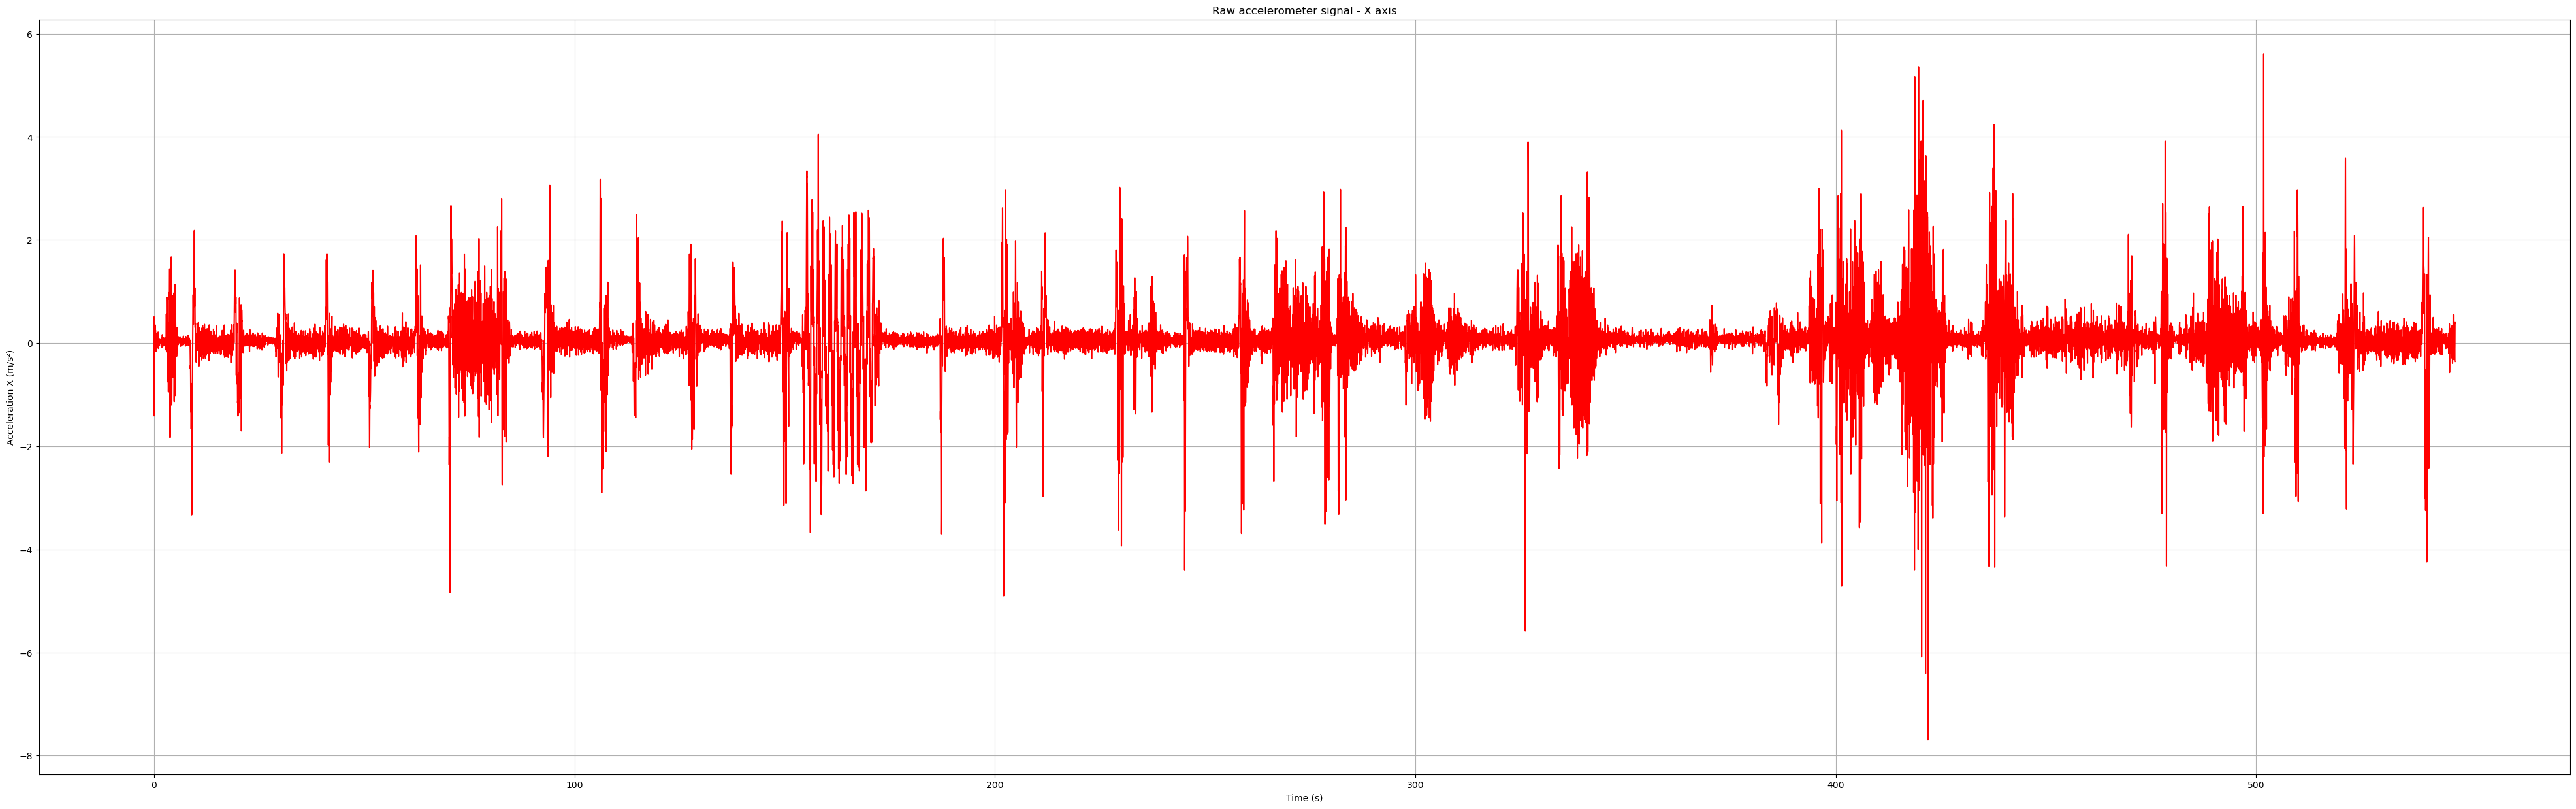

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(50,15))
plt.plot(df["Time (s)"], df["X (m/s^2)"], color="red")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration X (m/s²)")
plt.title("Raw accelerometer signal - X axis")
plt.grid(True)
plt.box(True)
plt.show()

- Y axis : 

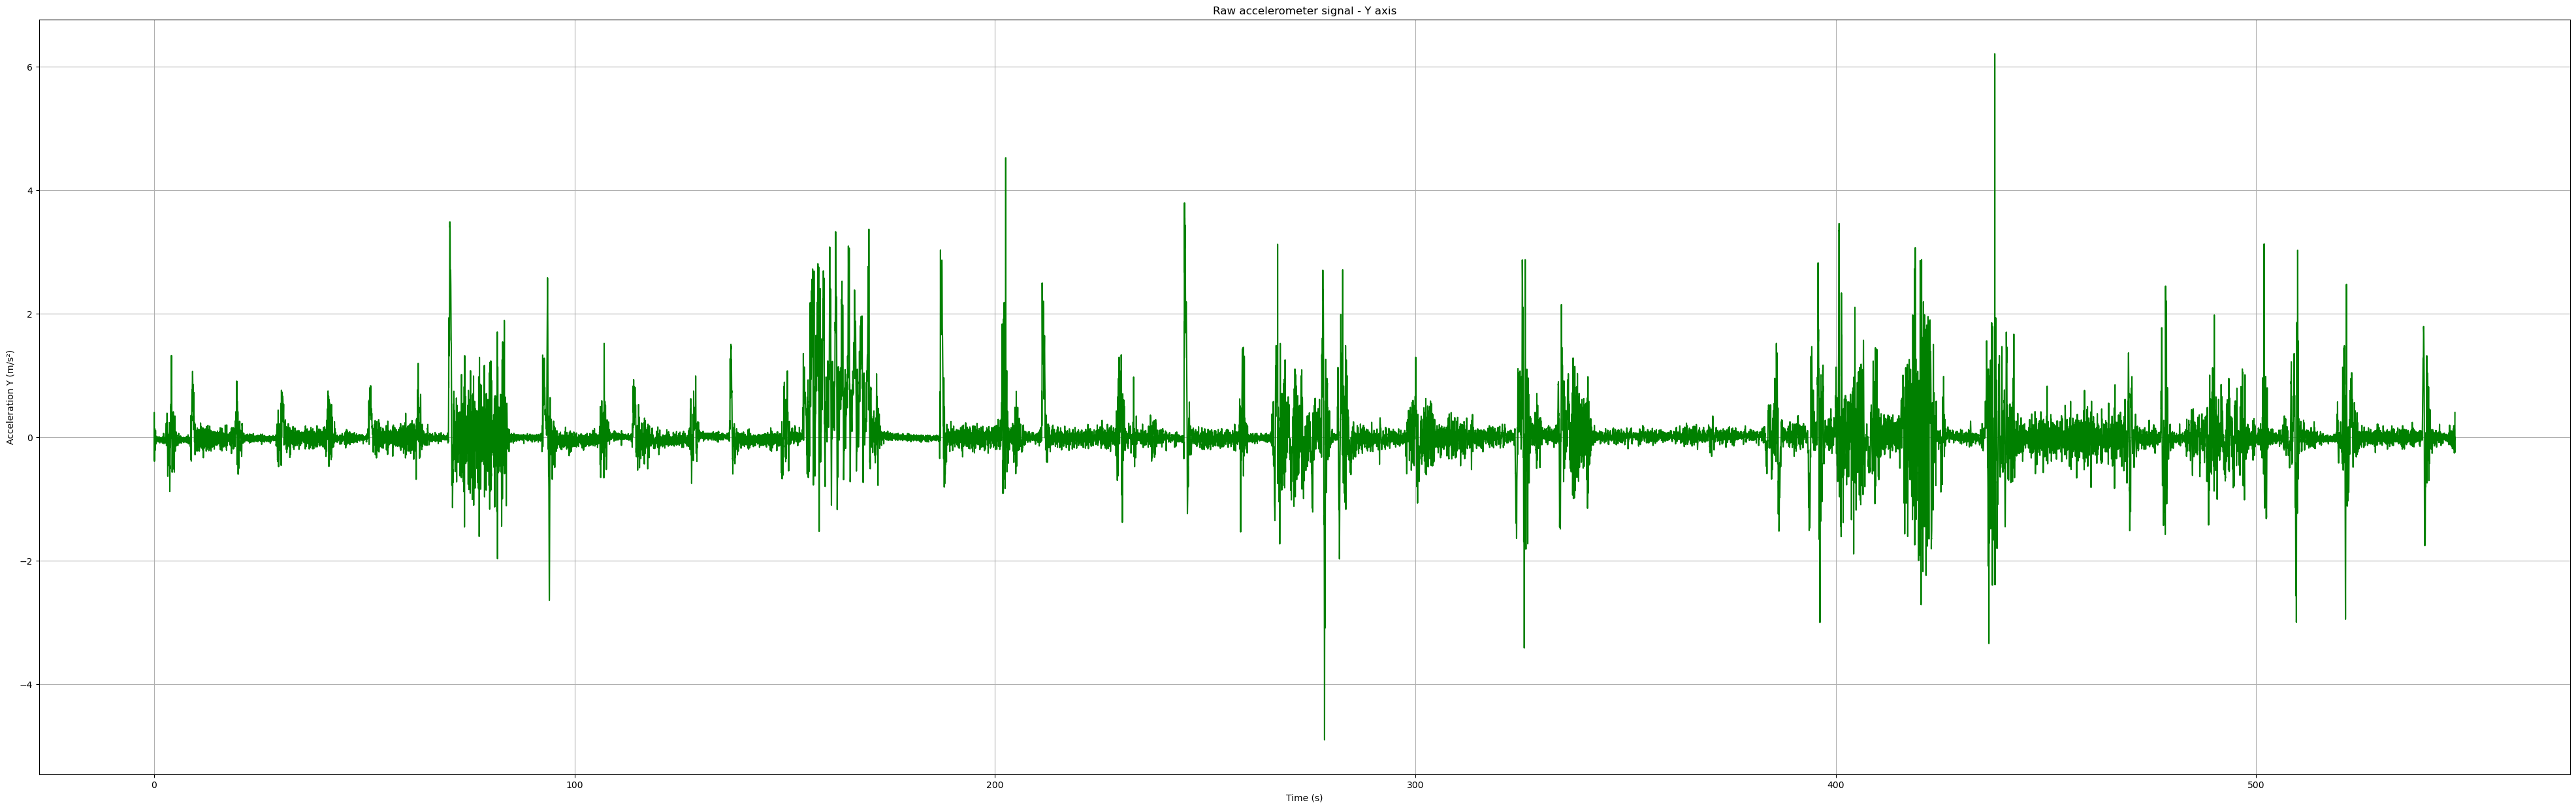

In [50]:
plt.figure(figsize=(50,15))
plt.plot(df["Time (s)"], df["Y (m/s^2)"], color="green")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration Y (m/s²)")
plt.title("Raw accelerometer signal - Y axis")
plt.grid(True)
plt.box(True)
plt.show()

- Z axis : 

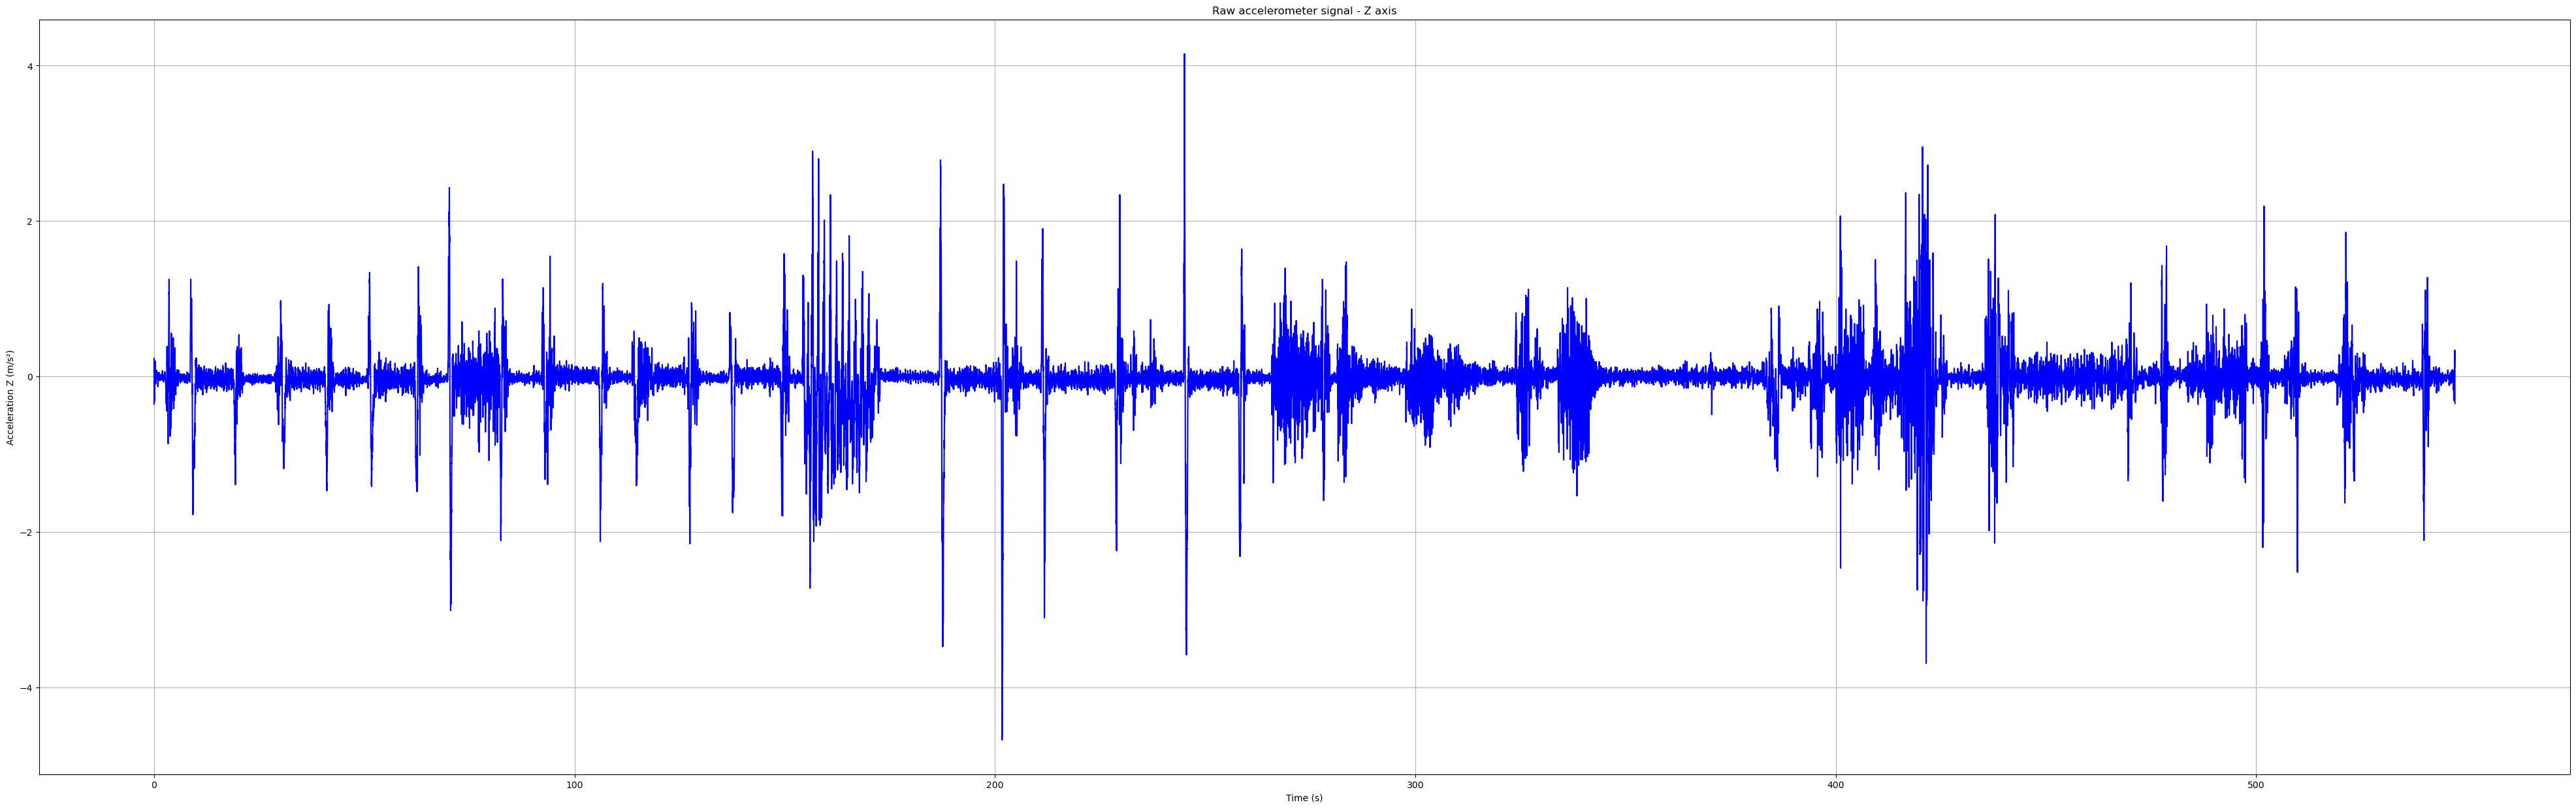

In [51]:
plt.figure(figsize=(50,15))
plt.plot(df["Time (s)"], df["Z (m/s^2)"], color="blue")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration Z (m/s²)")
plt.title("Raw accelerometer signal - Z axis")
plt.grid(True)
plt.box(True)
plt.show()

### 3. Calculat magnitude - Global signal

The magnitude of the accelerometer signal was calculated as the Euclidean norm of the three axes (X, Y, Z), providing a single signal that reflects the overall intensity of movement regardless of its direction.




We will compare the rest phase befor ansd after with a functionnal task wich is a grasping task of taking a glass and drink water. 
The signal was segmented into three phases based on the timeline: 
- 9,3 econd rest period before the task
- 18,75 second drinking task phase
- 10 second rest period after the task.

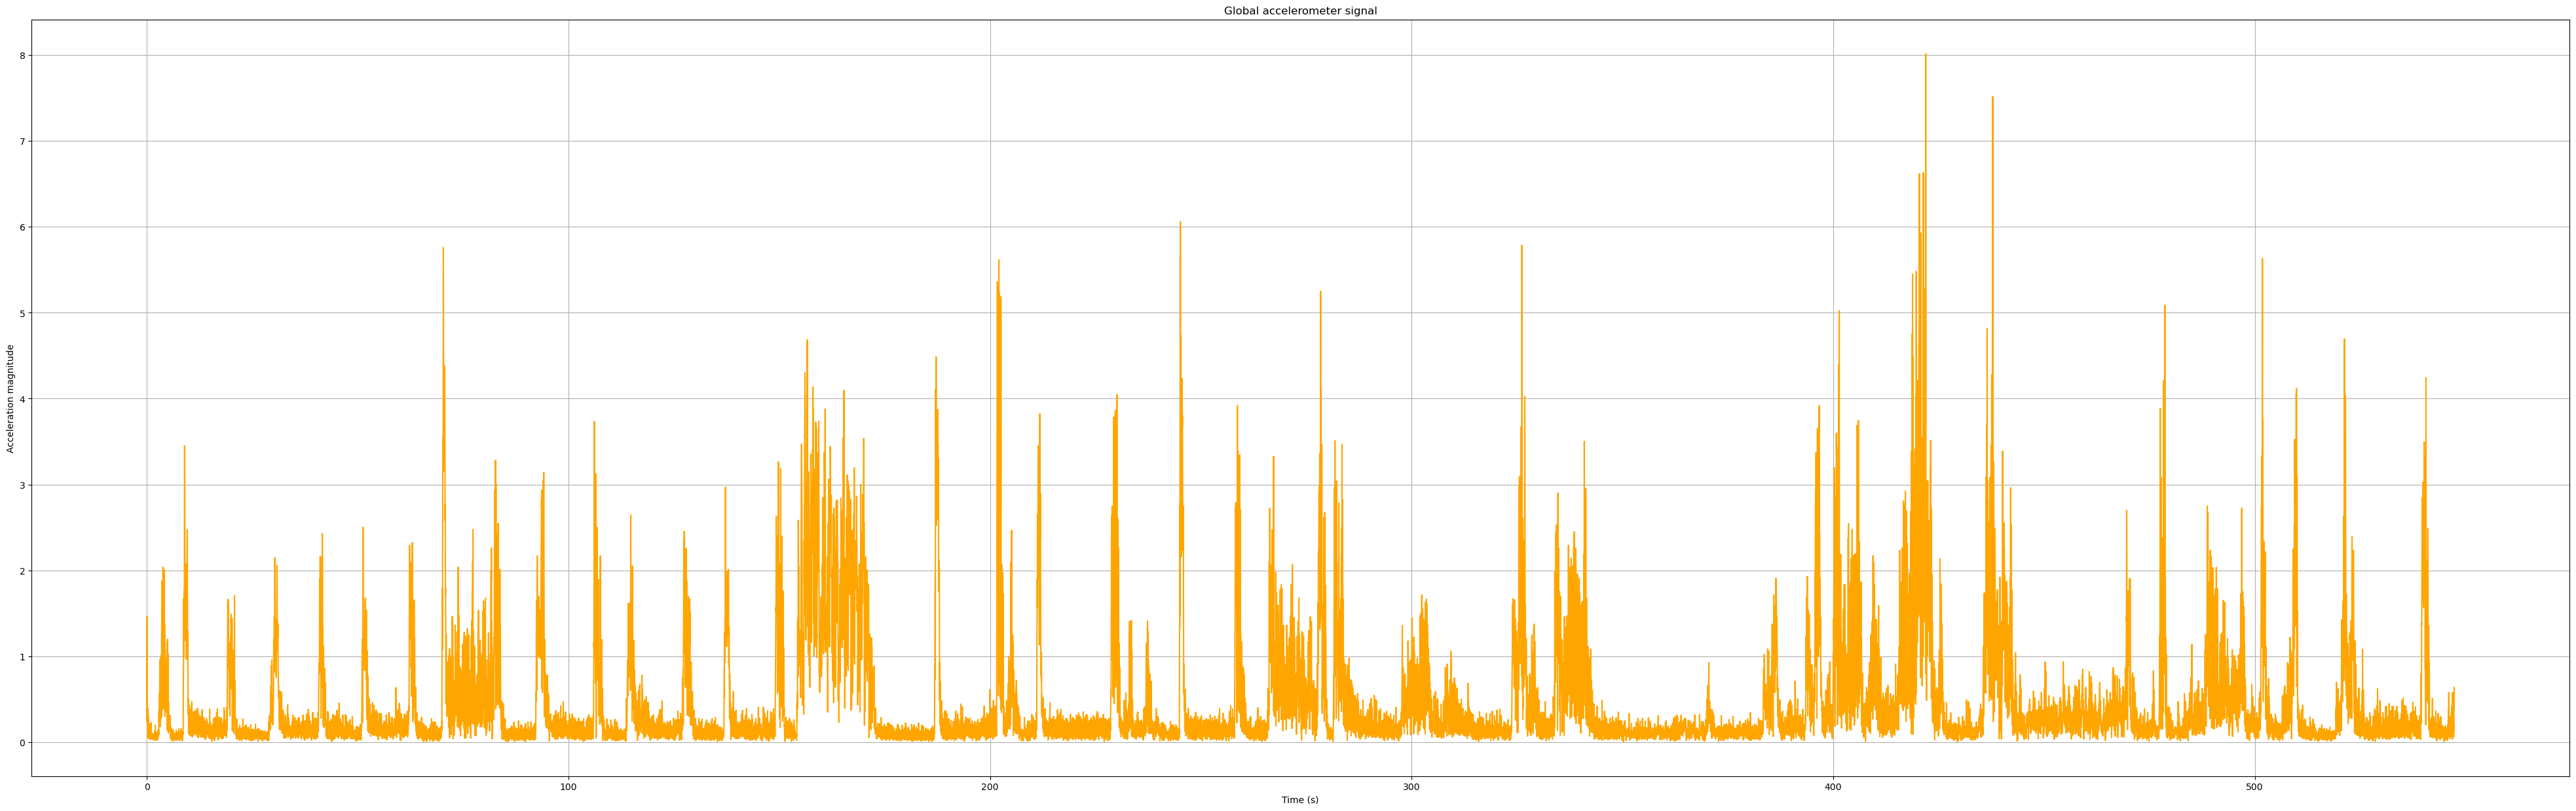

In [52]:
import numpy as np

df["magnitude"] = np.sqrt(
    df["X (m/s^2)"]**2 +
    df["Y (m/s^2)"]**2 +
    df["Z (m/s^2)"]**2
)

plt.figure(figsize=(50,15))
plt.plot(df["Time (s)"], df["magnitude"], color="orange")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration magnitude")
plt.title("Global accelerometer signal")
plt.grid(True)
plt.show()

### 4. Zoom on the task window :


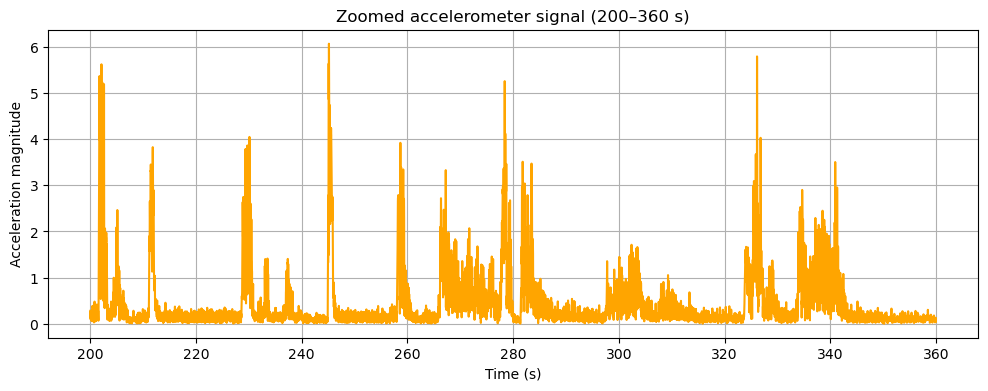

In [53]:
import matplotlib.pyplot as plt

# Sélection du segment
zoom_segment = df[(df["Time (s)"] >= 200) & (df["Time (s)"] <= 360)]

plt.figure(figsize=(12,4))

# Signal
plt.plot(zoom_segment["Time (s)"], zoom_segment["magnitude"], color="orange")

plt.xlabel("Time (s)")
plt.ylabel("Acceleration magnitude")
plt.title("Zoomed accelerometer signal (200–360 s)")
plt.grid(True)

plt.show()

### 5. separate rest and task phases: 

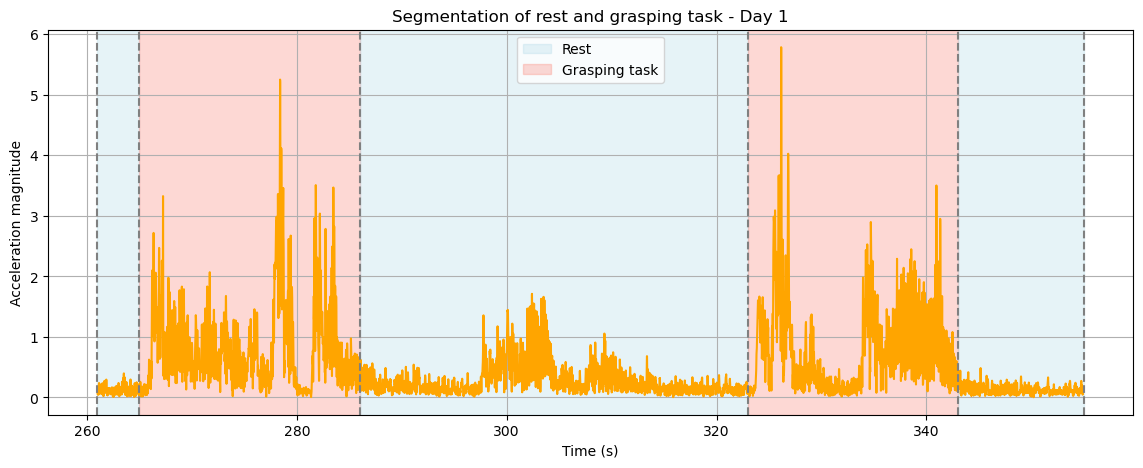

In [55]:
import matplotlib.pyplot as plt

# Segment times for Day 1
start_total_d1 = 261
rest1_start_d1 = 261
rest1_end_d1 = 265

task1_start_d1 = 265
task1_end_d1 = 286

rest2_start_d1 = 286
rest2_end_d1 = 323

task2_start_d1 = 323
task2_end_d1 = 343

rest3_start_d1 = 343
rest3_end_d1 = 355
end_total_d1 = 355

# Select the segment
segment_j1 = df[(df["Time (s)"] >= start_total_d1) & (df["Time (s)"] <= end_total_d1)]

plt.figure(figsize=(14,5))

# Plot signal
plt.plot(segment_j1["Time (s)"], segment_j1["magnitude"], color="orange")

# Background colors
plt.axvspan(rest1_start_d1, rest1_end_d1, color="lightblue", alpha=0.3, label="Rest")
plt.axvspan(task1_start_d1, task1_end_d1, color="salmon", alpha=0.3, label="Grasping task")
plt.axvspan(rest2_start_d1, rest2_end_d1, color="lightblue", alpha=0.3)
plt.axvspan(task2_start_d1, task2_end_d1, color="salmon", alpha=0.3)
plt.axvspan(rest3_start_d1, rest3_end_d1, color="lightblue", alpha=0.3)

# Separation lines
for x in [start_total_d1, rest1_end_d1, task1_end_d1, rest2_end_d1, task2_end_d1, rest3_end_d1]:
    plt.axvline(x, linestyle="--", color="gray")

# Labels
plt.xlabel("Time (s)")
plt.ylabel("Acceleration magnitude")
plt.title("Segmentation of rest and grasping task - Day 1")
plt.grid(True)
plt.legend()

plt.show()


During the resting period between the two grasping tasks, a low-amplitude residual signal is still observable. This background activity reflect small involuntary movements. 

The signal amplitude during rest significantly lower than during the grasping task, confirming a clear distinction between active ans resting phases.

### 6. Frequency analysis

To characterize the tremor, the accelerometer signal was transformed into the frequency domain using a Fast Fourier Transform (FFT). 

The analysis was performed separately for each segment (rest and grasping tasks) previously identified. 

To focus on tremor-related activity, only the frequency band between 3 and 8 Hz was considered, as this range corresponds to typical cerebellar tremor frequencies.
Now we can answer the question : 

**" What is the frequency of the tremor oscillation ?"**

#### 6.1. Rest 1 on day 1 :
The first rest phase was isolated, and the dominant frequency was computed using FFT.

Dominant frequency - Rest 1 on Day 1: 3.266331658291457 Hz
RMS amplitude - Rest 1 on Day 1: 0.07145669545825618


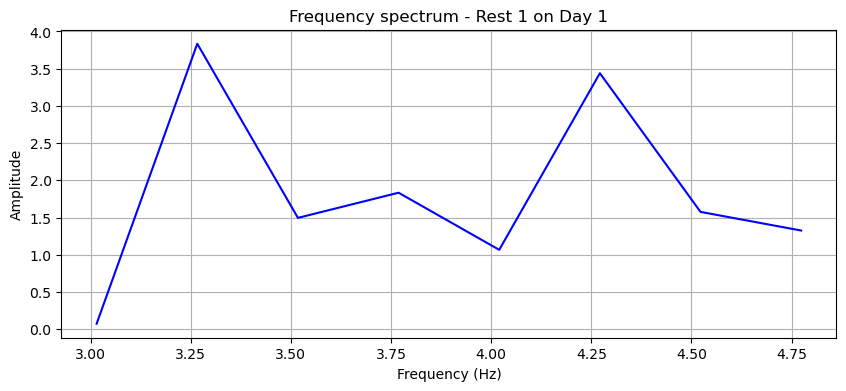

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Define Rest 1 - Day 1
rest1_d1 = df[(df["Time (s)"] >= 261) & (df["Time (s)"] <= 265)]

# Signal
signal_rest1_d1 = rest1_d1["magnitude"].values

# Remove mean
signal_centered_rest1_d1 = signal_rest1_d1 - np.mean(signal_rest1_d1)

# Sampling frequency
fs = 100

# FFT
fft_vals_rest1_d1 = np.abs(np.fft.fft(signal_centered_rest1_d1))
freqs_rest1_d1 = np.fft.fftfreq(len(signal_centered_rest1_d1), d=1/fs)

# Keep positive frequencies
positive_freqs_rest1_d1 = freqs_rest1_d1[:len(freqs_rest1_d1)//2]
positive_fft_rest1_d1 = fft_vals_rest1_d1[:len(fft_vals_rest1_d1)//2]

# Mask 3–5 Hz
mask_rest1_d1 = (positive_freqs_rest1_d1 >= 3) & (positive_freqs_rest1_d1 <= 5)

# Dominant frequency
dominant_freq_rest1_d1 = positive_freqs_rest1_d1[mask_rest1_d1][
    np.argmax(positive_fft_rest1_d1[mask_rest1_d1])
]

print("Dominant frequency - Rest 1 on Day 1:", dominant_freq_rest1_d1, "Hz")

# RMS amplitude
rms_rest1_d1 = np.sqrt(np.mean(signal_centered_rest1_d1**2))
print("RMS amplitude - Rest 1 on Day 1:", rms_rest1_d1)

# Plot frequency spectrum
plt.figure(figsize=(10,4))
plt.plot(
    positive_freqs_rest1_d1[mask_rest1_d1],
    positive_fft_rest1_d1[mask_rest1_d1],
    color="blue"
)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Rest 1 on Day 1")
plt.grid(True)
plt.show()

The dominant frequency observed during the task (~5.2 Hz) falls within the range reported for cerebellar tremor (typically 3–5 Hz). This supports the hypothesis that the observed oscillations correspond to an intention tremor.

In contrast, although a frequency was detected during rest, its very low amplitude suggests that it reflects background noise rather than a true tremor.

#### 6.2. task 1 on day 1 :
The first grasping phase was isolated, and the dominant frequency was computed using FFT.

Dominant frequency - Task 1: 3.7249283667621778 Hz


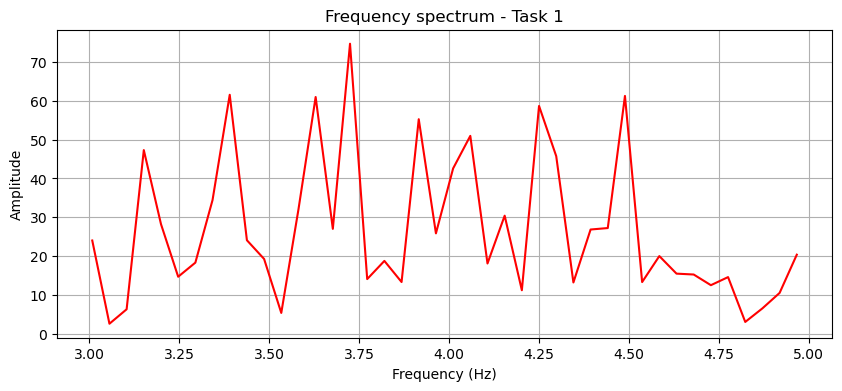

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Define Task 1
task1 = df[(df["Time (s)"] >= 265) & (df["Time (s)"] <= 286)]

# Signal
signal_task1 = task1["magnitude"].values

# Remove mean
signal_centered_task1 = signal_task1 - np.mean(signal_task1)

# Sampling frequency
fs = 100

# FFT
fft_vals_task1 = np.abs(np.fft.fft(signal_centered_task1))
freqs_task1 = np.fft.fftfreq(len(signal_centered_task1), d=1/fs)

# Keep positive frequencies
positive_freqs_task1 = freqs_task1[:len(freqs_task1)//2]
positive_fft_task1 = fft_vals_task1[:len(fft_vals_task1)//2]

# Mask 3–5 Hz
mask_task1 = (positive_freqs_task1 >= 3) & (positive_freqs_task1 <= 5)

# Dominant frequency
dominant_freq_task1 = positive_freqs_task1[mask_task1][np.argmax(positive_fft_task1[mask_task1])]

print("Dominant frequency - Task 1:", dominant_freq_task1, "Hz")

plt.figure(figsize=(10,4))
plt.plot(positive_freqs_task1[mask_task1], positive_fft_task1[mask_task1], color="red")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Task 1")
plt.grid(True)
plt.show()


To reduce the influence of slow voluntary movement, the dominant tremor frequency was searched within the 3–5 Hz frequency band.
Cerebellar tremor is typically characterized by a low frequency, usually below 5 Hz (Deuschl et al., 1998).


In [ ]:
signal_task1 = task1["magnitude"].values
signal_centered_task1 = signal_task1 - np.mean(signal_task1)

rms_task1 = np.sqrt(np.mean(signal_centered_task1**2))
print("RMS amplitude - Task 1:", rms_task1)

RMS amplitude - Task 1: 0.6925329650260768


Even though comparable frequencies were detected in both conditions, the much higher RMS amplitude during the task confirms the presence of a true tremor, while the resting signal remains negligible and likely corresponds to background noise.

-----------------------------------------------------------------------------------------------------------------------------------

## 2.  Rest 2 - Day 1 

### 2.1. Define the segment  


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define Rest 2
rest2 = df[(df["Time (s)"] >= 286) & (df["Time (s)"] <= 323)]

# Signal
signal_rest2 = rest2["magnitude"].values

# Remove mean
signal_centered_rest2 = signal_rest2 - np.mean(signal_rest2)

### 2.2. Compute dominant frequency (3–5 Hz band)  


In [ ]:

# Sampling frequency
fs = 100

# FFT
fft_vals_rest2 = np.abs(np.fft.fft(signal_centered_rest2))
freqs_rest2 = np.fft.fftfreq(len(signal_centered_rest2), d=1/fs)

# Keep positive frequencies
positive_freqs_rest2 = freqs_rest2[:len(freqs_rest2)//2]
positive_fft_rest2 = fft_vals_rest2[:len(fft_vals_rest2)//2]

# Mask 3–5 Hz
mask_rest2 = (positive_freqs_rest2 >= 3) & (positive_freqs_rest2 <= 5)

# Dominant frequency
dominant_freq_rest2 = positive_freqs_rest2[mask_rest2][np.argmax(positive_fft_rest2[mask_rest2])]

print("Dominant frequency - Rest Phase 2:", dominant_freq_rest2, "Hz")

Dominant frequency - Rest Phase 2: 4.690889370932754 Hz


### 2.3. Compute RMS amplitude  
 

In [ ]:
signal_rest2 = rest2["magnitude"].values
signal_centered_rest2 = signal_rest2 - np.mean(signal_rest2)

rms_rest2 = np.sqrt(np.mean(signal_centered_rest2**2))
print("RMS amplitude - Rest Phase 2:", rms_rest2)

RMS amplitude - Rest Phase 2: 0.2552581891472733


### 2.4. Plot the frequency spectrum 

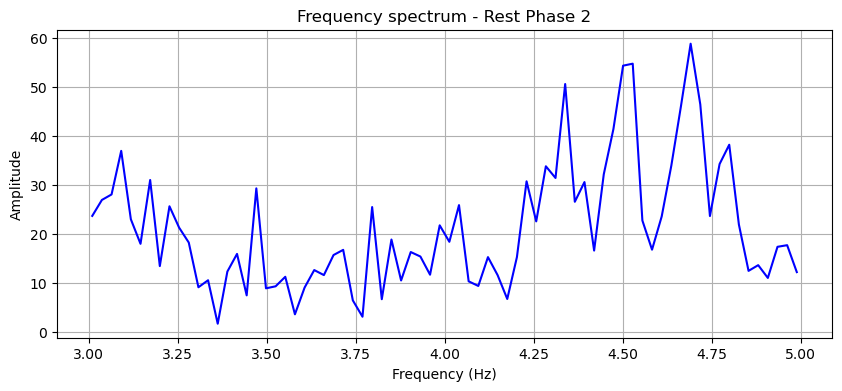

In [ ]:
# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_rest2[mask_rest2], positive_fft_rest2[mask_rest2], color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Rest Phase 2")
plt.grid(True)
plt.show()

During the resting phase 2, the dominant frequency was found at 4.69 Hz. But unlike the first resting phase, the signal amplitude was noticeably higher.

This increase in amplitude around 300 s on the time-domain signal is caused by involuntary movements of the patient. The patient has difficulties returning to a stable resting phase with his arm after a grasping task.

That is why we should carefully interpret these frequencies, because there are many artifacts linked to the initial motor task. These artifacts can artificially influence the frequency analysis.

This suggests that the observed oscillations during this phase are more likely to be interpreted as noise or transient movements rather than a true pathological tremor.

-----------------------------------------------------------------------------------------------------------------------------------

## 3.  Task 2 - Day 1 

### 3.1. Define the segment  


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define Task 2
task2 = df[(df["Time (s)"] >= 323) & (df["Time (s)"] <= 343)]

# Signal
signal_task2 = task2["magnitude"].values

# Remove mean
signal_centered_task2 = signal_task2 - np.mean(signal_task2)

### 3.2. Compute dominant frequency (3–5 Hz band)  


In [ ]:
# Sampling frequency
fs = 100

# FFT
fft_vals_task2 = np.abs(np.fft.fft(signal_centered_task2))
freqs_task2 = np.fft.fftfreq(len(signal_centered_task2), d=1/fs)

# Keep positive frequencies
positive_freqs_task2 = freqs_rest2[:len(freqs_task2)//2]
positive_fft_task2 = fft_vals_task2[:len(fft_vals_task2)//2]

# Mask 3–5 Hz
mask_task2 = (positive_freqs_task2 >= 3) & (positive_freqs_task2 <= 5)

# Dominant frequency
dominant_freq_task2 = positive_freqs_task2[mask_task2][np.argmax(positive_fft_task2[mask_task2])]

print("Dominant frequency - Task 2:", dominant_freq_task2, "Hz")

Dominant frequency - Task 2: 3.6334056399132315 Hz


### 3.3. Compute RMS amplitude  
 

In [ ]:
signal_task2 = task2["magnitude"].values
signal_centered_task2 = signal_task2 - np.mean(signal_task2)

rms_task2 = np.sqrt(np.mean(signal_centered_task2**2))
print("RMS amplitude - Task 2:", rms_task2)

RMS amplitude - Task 2: 0.7235343040843559


### 3.4. Plot the frequency spectrum 

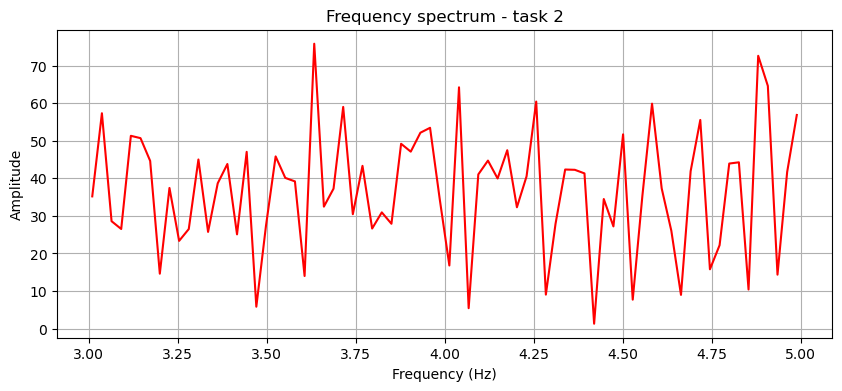

In [ ]:
# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_task2[mask_task2], positive_fft_task2[mask_task2], color="red")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - task 2")
plt.grid(True)
plt.show()

During the second grasping task, the dominant frequency was found at approximately 3.63 Hz, which remains within the typical range of cerebellar tremor (3–5 Hz).

The RMS amplitude is relatively high compared to the resting phases, confirming that the signal corresponds to an active movement condition with a clear oscillatory component.

This indicates that the tremor is functionally expressed during the task, and not during rest. The frequency remains consistent with what is expected for an intention tremor, even if it is slightly lower than in Task 1.

Overall, Task 2 confirms the presence of a tremor during voluntary movement, with a frequency in the pathological range and a significant amplitude.

-----------------------------------------------------------------------------------------------------------------------------------

## 4.  Rest 3 - Day 1 

### 4.1. Define the segment  



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define Rest 3
rest3 = df[(df["Time (s)"] >= 343) & (df["Time (s)"] <= 355)]

# Signal
signal_rest3 = rest3["magnitude"].values

# Remove mean
signal_centered_rest3 = signal_rest3 - np.mean(signal_rest3)

### 4.2. Compute dominant frequency (3–5 Hz band)  


In [ ]:

# Sampling frequency
fs = 100

# FFT
fft_vals_rest3 = np.abs(np.fft.fft(signal_centered_rest3))
freqs_rest3 = np.fft.fftfreq(len(signal_centered_rest3), d=1/fs)

# Keep positive frequencies
positive_freqs_rest3 = freqs_rest3[:len(freqs_rest3)//2]
positive_fft_rest3 = fft_vals_rest3[:len(fft_vals_rest3)//2]

# Mask 3–5 Hz
mask_rest3 = (positive_freqs_rest3 >= 3) & (positive_freqs_rest3 <= 5)

# Dominant frequency
dominant_freq_rest3 = positive_freqs_rest3[mask_rest3][np.argmax(positive_fft_rest3[mask_rest3])]

print("Dominant frequency - Rest Phase 3:", dominant_freq_rest3, "Hz")

Dominant frequency - Rest Phase 3: 4.849498327759197 Hz


### 4.3. Compute RMS amplitude  
 

In [ ]:
signal_rest3 = rest3["magnitude"].values
signal_centered_rest3 = signal_rest3 - np.mean(signal_rest3)

rms_rest3 = np.sqrt(np.mean(signal_centered_rest3**2))
print("RMS amplitude - Rest Phase 3:", rms_rest3)

RMS amplitude - Rest Phase 3: 0.07124664516774774


### 4.4. Plot the frequency spectrum 

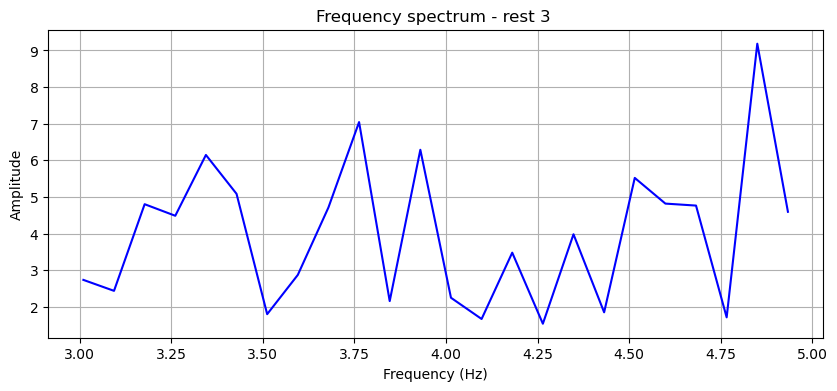

In [ ]:
# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_rest3[mask_rest3], positive_fft_rest3[mask_rest3], color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - rest 3 ")
plt.grid(True)
plt.show()

During the third resting phase, the dominant frequency was found at approximately 4.85 Hz. This value still falls within the 3–5 Hz range typically associated with cerebellar tremor.

However, the RMS amplitude was very low (≈ 0.07), which indicates that the overall signal intensity was minimal. This suggests that the subject was in a more stable resting condition compared to Rest 2.

Therefore, although a frequency component within the tremor range was detected, the very low amplitude indicates that this activity is likely not representative of a true tremor. Instead, it more likely reflects background noise or minimal physiological variability.

This confirms that, in the absence of voluntary movement, the tremor is not significantly expressed.

Rest Phase 3 reinforces the observation that tremor expression is minimal at rest and mainly emerges during voluntary movement.

At this stage, the analysis of Day 1 is completed for all segments, including both resting and grasping phases. The next step is to organize the extracted results into a structured table, including the dominant frequency and RMS amplitude for each phase.

This table will be exported as a CSV file and will serve as the basis for further analysis. 

In the following steps, the same procedure will be applied to Day 2 and Day 3 in order to assess the reproducibility of the tremor.

Finally, all datasets will be combined and analyzed using R to perform statistical comparisons and generate clear visualizations of tremor frequency and amplitude across conditions and days.

In [ ]:
import pandas as pd

results_day1 = pd.DataFrame({
    "Phase": ["Rest1", "Task1", "Rest2", "Task2", "Rest3"],
    "Dominant_Frequency_Hz": [
        dominant_freq_rest1,
        dominant_freq_task1,
        dominant_freq_rest2,
        dominant_freq_task2,
        dominant_freq_rest3
    ],
    "RMS_Amplitude": [
        rms_rest1,
        rms_task1,
        rms_rest2,
        rms_task2,
        rms_rest3
    ]
})
results_day1 = results_day1.round(2)

results_day1

,Phase,Dominant_Frequency_Hz,RMS_Amplitude
0,Rest1,3.27,0.07
1,Task1,3.72,0.69
2,Rest2,4.69,0.26
3,Task2,3.63,0.72
4,Rest3,4.85,0.07


In [ ]:
results_day1.to_csv("data/processed_data/results_day1.csv", index=False)

## ------------------------------- DAY 2 --------------------------------

### 1. Import J2_P01.csv


In [13]:
import pandas as pd

df_2 = pd.read_csv("data/raw_data/J2_P01.csv")
df.head()

,Time (s),X (m/s^2),Y (m/s^2),Z (m/s^2),magnitude
0,0.002665,0.506471,-0.356188,0.234163,0.661978
1,0.012697,0.032052,-0.225771,-0.058613,0.235447
2,0.022728,-1.409056,0.168511,-0.354232,1.462639
3,0.032759,-0.614877,0.402211,-0.335070,0.807539
4,0.042790,-0.136440,0.013456,-0.319703,0.347860


In [ ]:
print(df_2.columns)
print(df_2.shape)

Index(['Time (s)', 'X (m/s^2)', 'Y (m/s^2)', 'Z (m/s^2)'], dtype='object')
(54205, 4)


### 2. Draw the signal

Plot the raw signals

- X axis :


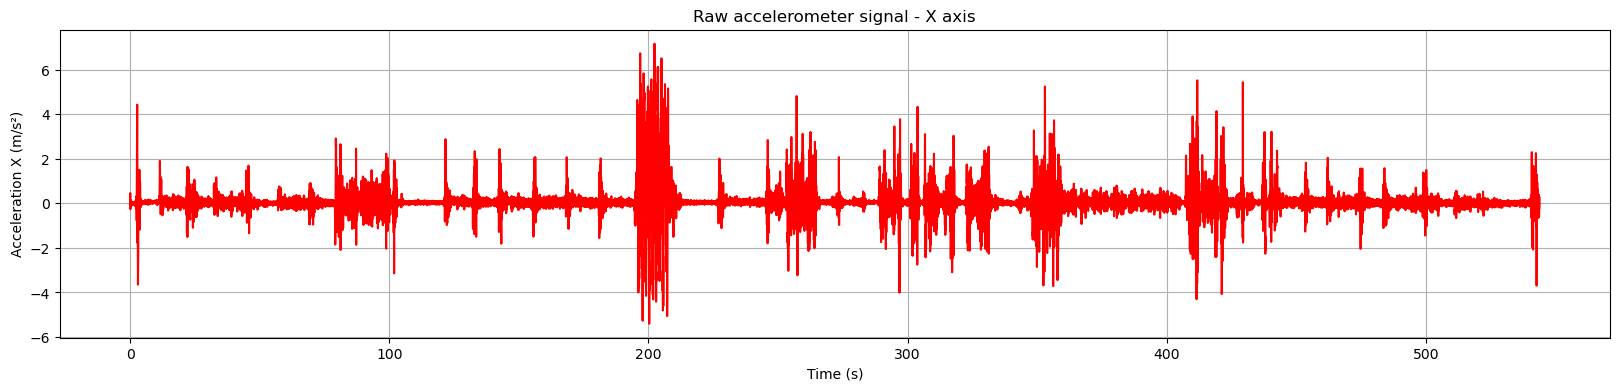

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,4))
plt.plot(df_2["Time (s)"], df_2["X (m/s^2)"], color="red")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration X (m/s²)")
plt.title("Raw accelerometer signal - X axis")
plt.grid(True)
plt.box(True)
plt.show()


- Y axis: 

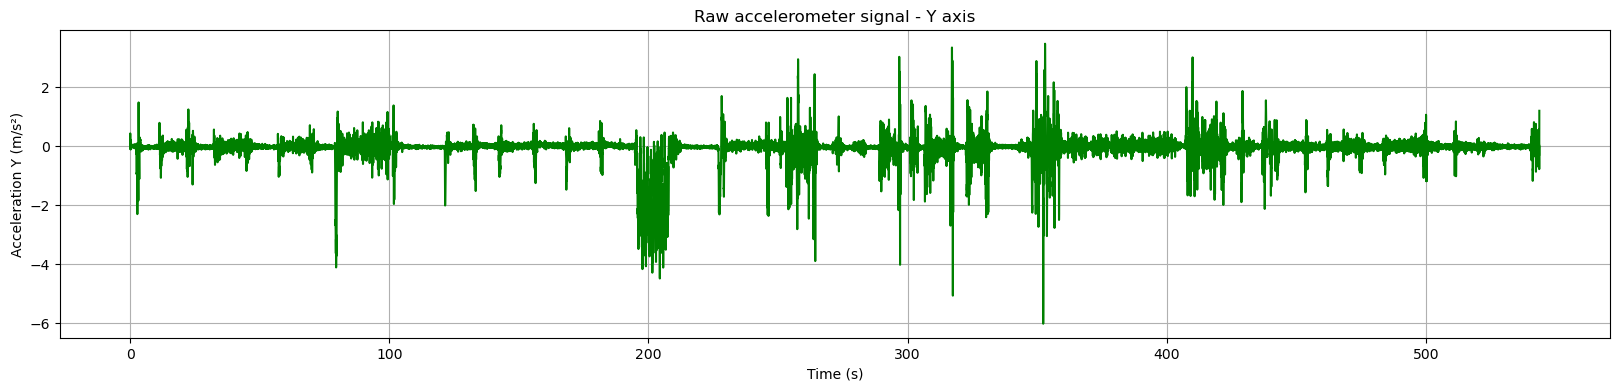

In [15]:
plt.figure(figsize=(20,4))
plt.plot(df_2["Time (s)"], df_2["Y (m/s^2)"], color="green")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration Y (m/s²)")
plt.title("Raw accelerometer signal - Y axis")
plt.grid(True)
plt.box(True)
plt.show()

- Z axis :

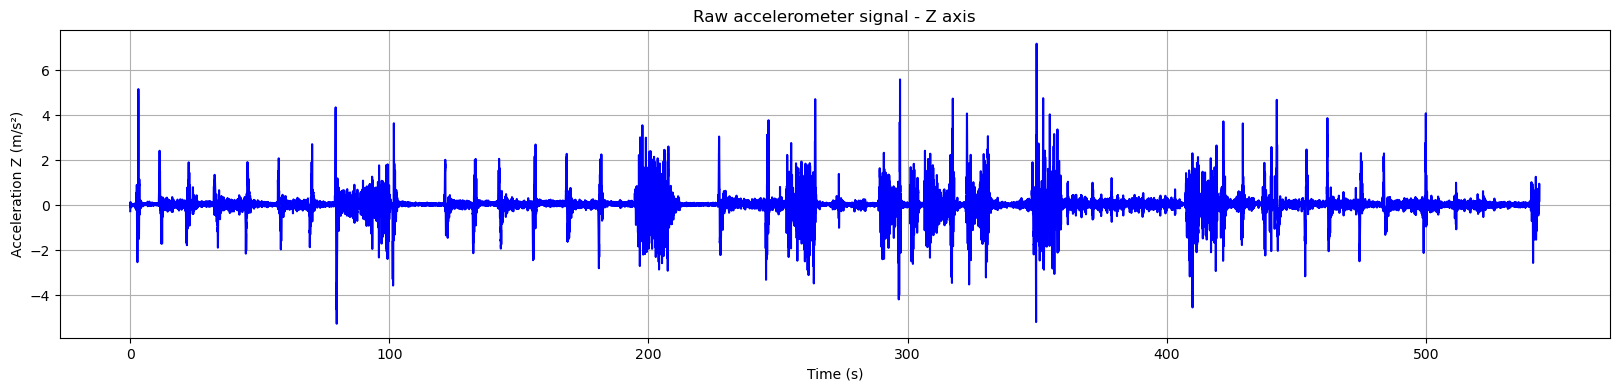

In [16]:
plt.figure(figsize=(20,4))
plt.plot(df_2["Time (s)"], df_2["Z (m/s^2)"], color="blue")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration Z (m/s²)")
plt.title("Raw accelerometer signal - Z axis")
plt.grid(True)
plt.box(True)
plt.show()


### 3. Calculat magnitude - Global signal  


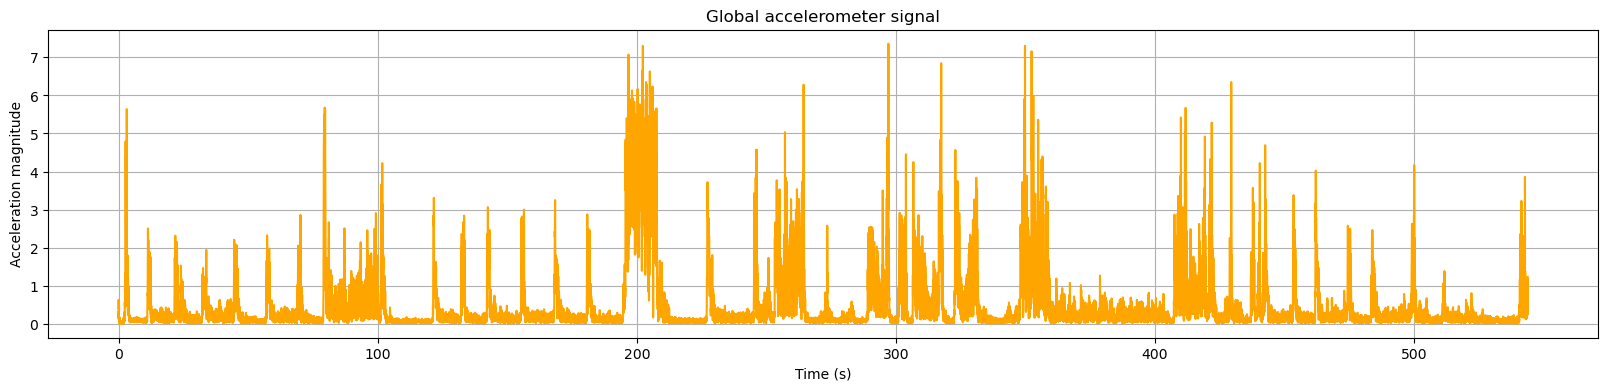

In [17]:
import numpy as np

df_2["magnitude"] = np.sqrt(
    df_2["X (m/s^2)"]**2 +
    df_2["Y (m/s^2)"]**2 +
    df_2["Z (m/s^2)"]**2
)

plt.figure(figsize=(20,4))
plt.plot(df_2["Time (s)"], df_2["magnitude"], color="orange")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration magnitude")
plt.title("Global accelerometer signal")
plt.grid(True)
plt.show()

### 4. Zoom on the task window :

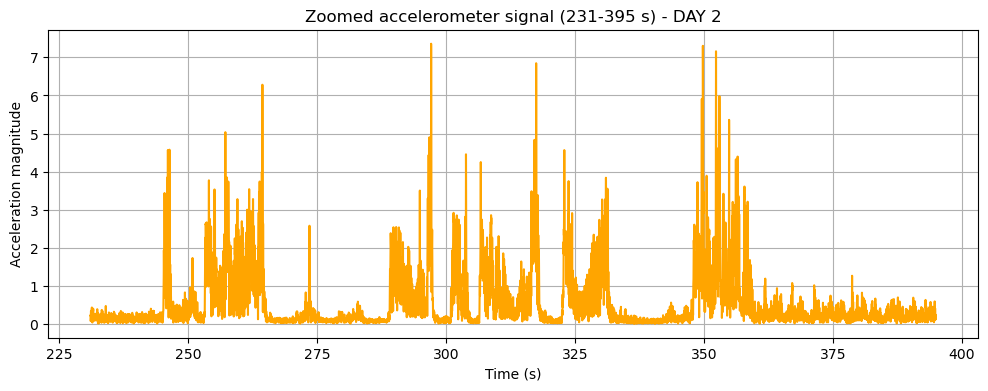

In [18]:
import matplotlib.pyplot as plt

# Sélection du segment
zoom_segment2 = df_2[(df_2["Time (s)"] >= 231) & (df_2["Time (s)"] <= 395)]

plt.figure(figsize=(12,4))

# Signal
plt.plot(zoom_segment2["Time (s)"], zoom_segment2["magnitude"], color="orange")

plt.xlabel("Time (s)")
plt.ylabel("Acceleration magnitude")
plt.title("Zoomed accelerometer signal (231-395 s) - DAY 2")
plt.grid(True)

plt.show()

### 5. Segmenter rest / task


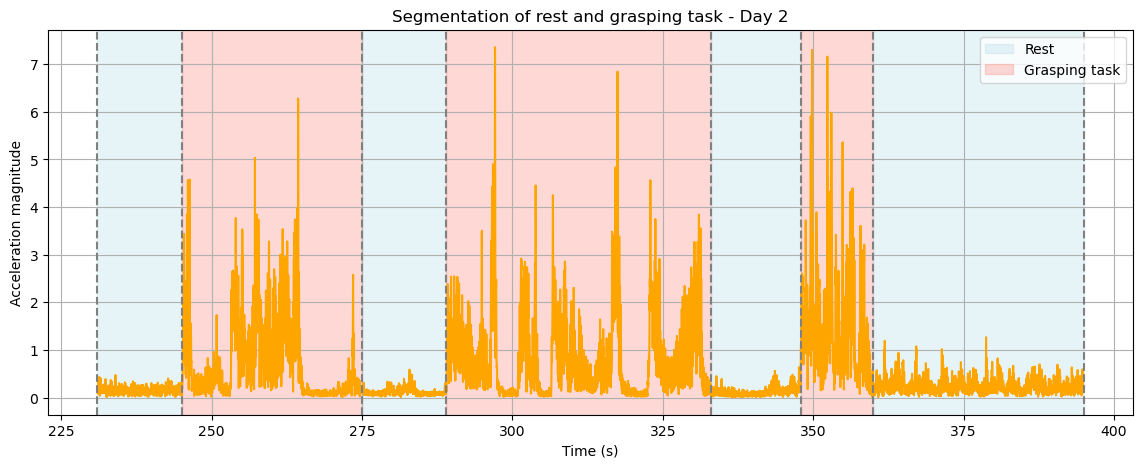

In [67]:
import matplotlib.pyplot as plt

# Segment times for Day 2
start_total_d2 = 231
rest1_start_d2 = 231
rest1_end_d2 = 245

task1_start_d2 = 245
task1_end_d2 = 275

rest2_start_d2 = 275
rest2_end_d2 = 289

task2_start_d2 = 289
task2_end_d2 = 333

rest3_start_d2 = 333
rest3_end_d2 = 348

task3_start_d2 = 348
task3_end_d2 = 360 

rest4_start_d2 = 360
rest4_end_d2 = 395
end_total_d2 = 395

# Select the segment
segment_j2 = df_2[(df_2["Time (s)"] >= start_total_d2) & (df_2["Time (s)"] <= end_total_d2)]

plt.figure(figsize=(14,5))

# Plot signal
plt.plot(segment_j2["Time (s)"], segment_j2["magnitude"], color="orange")

# Background colors
plt.axvspan(rest1_start_d2, rest1_end_d2, color="lightblue", alpha=0.3, label="Rest")
plt.axvspan(task1_start_d2, task1_end_d2, color="salmon", alpha=0.3, label="Grasping task")
plt.axvspan(rest2_start_d2, rest2_end_d2, color="lightblue", alpha=0.3)
plt.axvspan(task2_start_d2, task2_end_d2, color="salmon", alpha=0.3)
plt.axvspan(rest3_start_d2, rest3_end_d2, color="lightblue", alpha=0.3)
plt.axvspan(task3_start_d2, task3_end_d2, color="salmon", alpha=0.3)
plt.axvspan(rest4_start_d2, rest4_end_d2, color="lightblue", alpha=0.3)


# Separation lines
for x in [start_total_d2, rest1_end_d2, task1_end_d2, rest2_end_d2, task2_end_d2, rest3_end_d2,task3_end_d2,end_total_d2]:
    plt.axvline(x, linestyle="--", color="gray")

# Labels
plt.xlabel("Time (s)")
plt.ylabel("Acceleration magnitude")
plt.title("Segmentation of rest and grasping task - Day 2")
plt.grid(True)
plt.legend()

plt.show()

### 6. Frequency analysis ans calculate RMS 


#### 6.1.  Rest 1 on day 2 

Dominant frequency - Rest 1 on Day 2: 4.516129032258064 Hz


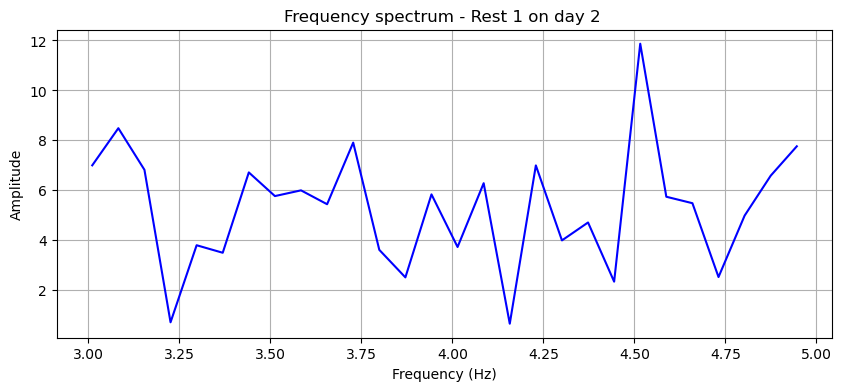

RMS amplitude - Rest 1 on day2 : 0.07710739506803857


In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Define Rest 1 (Day 2)
rest1_d2 = df_2[(df_2["Time (s)"] >= 231) & (df_2["Time (s)"] <= 245)]

# Signal
signal_rest1_d2 = rest1_d2["magnitude"].values

# Remove mean
signal_centered_rest1_d2 = signal_rest1_d2 - np.mean(signal_rest1_d2)

# Sampling frequency
fs = 100

# FFT
fft_vals_rest1_d2 = np.abs(np.fft.fft(signal_centered_rest1_d2))
freqs_rest1_d2 = np.fft.fftfreq(len(signal_centered_rest1_d2), d=1/fs)

# Keep positive frequencies
positive_freqs_rest1_d2 = freqs_rest1_d2[:len(freqs_rest1_d2)//2]
positive_fft_rest1_d2 = fft_vals_rest1_d2[:len(fft_vals_rest1_d2)//2]

# Mask 3–5 Hz
mask_rest1_d2 = (positive_freqs_rest1_d2 >= 3) & (positive_freqs_rest1_d2 <= 5)

# Dominant frequency
dominant_freq_rest1_d2 = positive_freqs_rest1_d2[mask_rest1_d2][
    np.argmax(positive_fft_rest1_d2[mask_rest1_d2])
]

print("Dominant frequency - Rest 1 on Day 2:", dominant_freq_rest1_d2, "Hz")

# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_rest1_d2[mask_rest1_d2], positive_fft_rest1_d2[mask_rest1_d2], color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Rest 1 on day 2 ")
plt.grid(True)
plt.show()
signal_rest1_d2 = rest1_d2["magnitude"].values
signal_centered_rest1_d2 = signal_rest1_d2 - np.mean(signal_rest1_d2)

rms_rest1_d2 = np.sqrt(np.mean(signal_centered_rest1_d2**2))
print("RMS amplitude - Rest 1 on day2 :", rms_rest1_d2)

#### 6.2.  Task 1 on day 2 : 

Dominant frequency - Task 1 on Day 2: 3.1772575250836117 Hz
RMS amplitude - Task 1 on Day 2: 0.8621551904932978


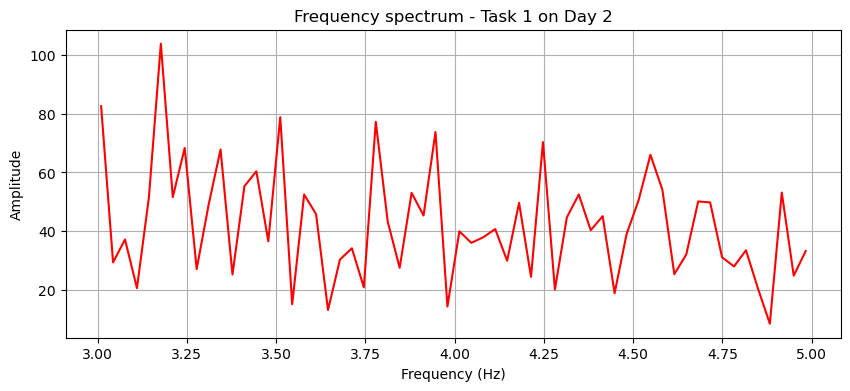

In [70]:
# Define Task 1 - Day 2
task1_d2 = df_2[(df_2["Time (s)"] >= 245) & (df_2["Time (s)"] <= 275)]

# Signal
signal_task1_d2 = task1_d2["magnitude"].values

# Remove mean
signal_centered_task1_d2 = signal_task1_d2 - np.mean(signal_task1_d2)

# Sampling frequency
fs = 100

# FFT
fft_vals_task1_d2 = np.abs(np.fft.fft(signal_centered_task1_d2))
freqs_task1_d2 = np.fft.fftfreq(len(signal_centered_task1_d2), d=1/fs)

# Keep positive frequencies
positive_freqs_task1_d2 = freqs_task1_d2[:len(freqs_task1_d2)//2]
positive_fft_task1_d2 = fft_vals_task1_d2[:len(fft_vals_task1_d2)//2]

# Mask 3–5 Hz
mask_task1_d2 = (positive_freqs_task1_d2 >= 3) & (positive_freqs_task1_d2 <= 5)

# Dominant frequency
dominant_freq_task1_d2 = positive_freqs_task1_d2[mask_task1_d2][np.argmax(positive_fft_task1_d2[mask_task1_d2])]

print("Dominant frequency - Task 1 on Day 2:", dominant_freq_task1_d2, "Hz")

# RMS amplitude
rms_task1_d2 = np.sqrt(np.mean(signal_centered_task1_d2**2))
print("RMS amplitude - Task 1 on Day 2:", rms_task1_d2)

# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_task1_d2[mask_task1_d2], positive_fft_task1_d2[mask_task1_d2], color="red")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Task 1 on Day 2")
plt.grid(True)
plt.show()

#### 6.3.  Rest 2 on day 2 : 

Dominant frequency - Rest 2 on Day 2: 4.7277936962750715 Hz
RMS amplitude - Rest 2 on Day 2: 0.07563217171767582


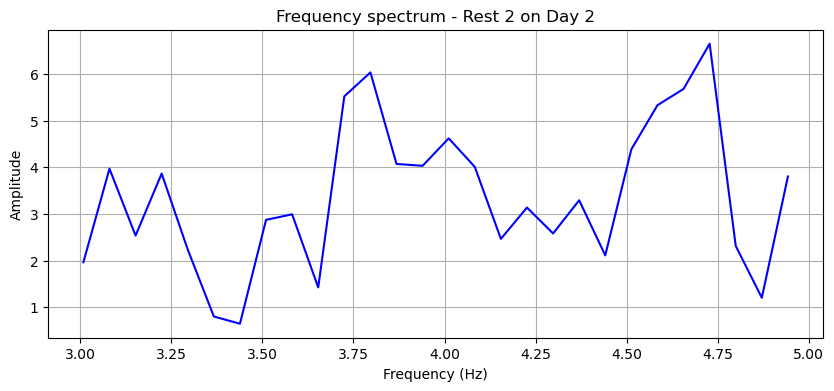

In [71]:
# Define Rest 2 - Day 2
rest2_d2 = df_2[(df_2["Time (s)"] >= 275) & (df_2["Time (s)"] <= 289)]

# Signal
signal_rest2_d2 = rest2_d2["magnitude"].values

# Remove mean
signal_centered_rest2_d2 = signal_rest2_d2 - np.mean(signal_rest2_d2)

# Sampling frequency
fs = 100

# FFT
fft_vals_rest2_d2 = np.abs(np.fft.fft(signal_centered_rest2_d2))
freqs_rest2_d2 = np.fft.fftfreq(len(signal_centered_rest2_d2), d=1/fs)

# Keep positive frequencies
positive_freqs_rest2_d2 = freqs_rest2_d2[:len(freqs_rest2_d2)//2]
positive_fft_rest2_d2 = fft_vals_rest2_d2[:len(fft_vals_rest2_d2)//2]

# Mask 3–5 Hz
mask_rest2_d2 = (positive_freqs_rest2_d2 >= 3) & (positive_freqs_rest2_d2 <= 5)

# Dominant frequency
dominant_freq_rest2_d2 = positive_freqs_rest2_d2[mask_rest2_d2][np.argmax(positive_fft_rest2_d2[mask_rest2_d2])]

print("Dominant frequency - Rest 2 on Day 2:", dominant_freq_rest2_d2, "Hz")

# RMS amplitude
rms_rest2_d2 = np.sqrt(np.mean(signal_centered_rest2_d2**2))
print("RMS amplitude - Rest 2 on Day 2:", rms_rest2_d2)

# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_rest2_d2[mask_rest2_d2], positive_fft_rest2_d2[mask_rest2_d2], color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Rest 2 on Day 2")
plt.grid(True)
plt.show()

#### 6.4 Task 2 on day 2 : 

Dominant frequency - Task 2 on Day 2: 4.149566803465572 Hz
RMS amplitude - Task 2 on Day 2: 0.8762796924510973


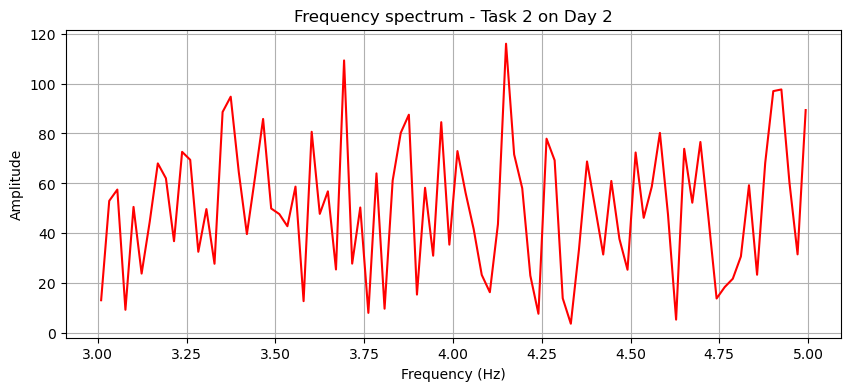

In [72]:
# Define Task 2 - Day 2
task2_d2 = df_2[(df_2["Time (s)"] >= 289) & (df_2["Time (s)"] <= 333)]

# Signal
signal_task2_d2 = task2_d2["magnitude"].values

# Remove mean
signal_centered_task2_d2 = signal_task2_d2 - np.mean(signal_task2_d2)

# Sampling frequency
fs = 100

# FFT
fft_vals_task2_d2 = np.abs(np.fft.fft(signal_centered_task2_d2))
freqs_task2_d2 = np.fft.fftfreq(len(signal_centered_task2_d2), d=1/fs)

# Keep positive frequencies
positive_freqs_task2_d2 = freqs_task2_d2[:len(freqs_task2_d2)//2]
positive_fft_task2_d2 = fft_vals_task2_d2[:len(fft_vals_task2_d2)//2]

# Mask 3–5 Hz
mask_task2_d2 = (positive_freqs_task2_d2 >= 3) & (positive_freqs_task2_d2 <= 5)

# Dominant frequency
dominant_freq_task2_d2 = positive_freqs_task2_d2[mask_task2_d2][np.argmax(positive_fft_task2_d2[mask_task2_d2])]

print("Dominant frequency - Task 2 on Day 2:", dominant_freq_task2_d2, "Hz")

# RMS amplitude
rms_task2_d2 = np.sqrt(np.mean(signal_centered_task2_d2**2))
print("RMS amplitude - Task 2 on Day 2:", rms_task2_d2)

# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_task2_d2[mask_task2_d2], positive_fft_task2_d2[mask_task2_d2], color="red")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Task 2 on Day 2")
plt.grid(True)
plt.show()

#### 6.5. Rest 3 on day 2 : 

Dominant frequency - Rest 3 on Day 2: 3.4782608695652173 Hz
RMS amplitude - Rest 3 on Day 2: 0.1165281678300835


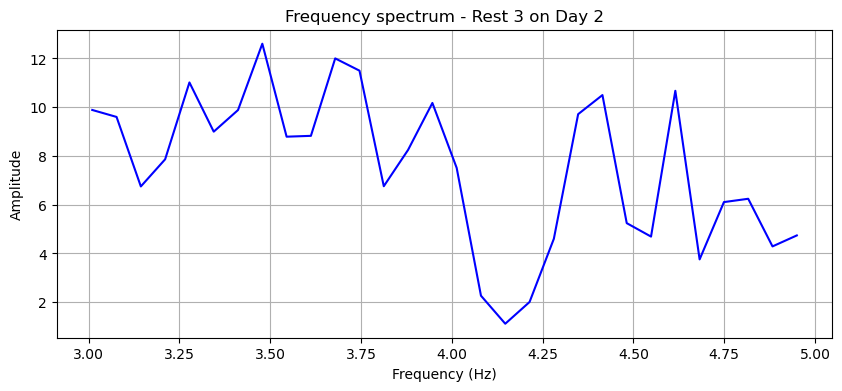

In [73]:
# Define Rest 3 - Day 2
rest3_d2 = df_2[(df_2["Time (s)"] >= 333) & (df_2["Time (s)"] <= 348)]

# Signal
signal_rest3_d2 = rest3_d2["magnitude"].values

# Remove mean
signal_centered_rest3_d2 = signal_rest3_d2 - np.mean(signal_rest3_d2)

# Sampling frequency
fs = 100

# FFT
fft_vals_rest3_d2 = np.abs(np.fft.fft(signal_centered_rest3_d2))
freqs_rest3_d2 = np.fft.fftfreq(len(signal_centered_rest3_d2), d=1/fs)

# Keep positive frequencies
positive_freqs_rest3_d2 = freqs_rest3_d2[:len(freqs_rest3_d2)//2]
positive_fft_rest3_d2 = fft_vals_rest3_d2[:len(fft_vals_rest3_d2)//2]

# Mask 3–5 Hz
mask_rest3_d2 = (positive_freqs_rest3_d2 >= 3) & (positive_freqs_rest3_d2 <= 5)

# Dominant frequency
dominant_freq_rest3_d2 = positive_freqs_rest3_d2[mask_rest3_d2][np.argmax(positive_fft_rest3_d2[mask_rest3_d2])]

print("Dominant frequency - Rest 3 on Day 2:", dominant_freq_rest3_d2, "Hz")

# RMS amplitude
rms_rest3_d2 = np.sqrt(np.mean(signal_centered_rest3_d2**2))
print("RMS amplitude - Rest 3 on Day 2:", rms_rest3_d2)

# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_rest3_d2[mask_rest3_d2], positive_fft_rest3_d2[mask_rest3_d2], color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Rest 3 on Day 2")
plt.grid(True)
plt.show()

#### 6.6 Task 3 on day 2 : 

Dominant frequency - Task 3 on Day 2: 3.177257525083612 Hz
RMS amplitude - Task 3 on Day 2: 1.1540581022511776


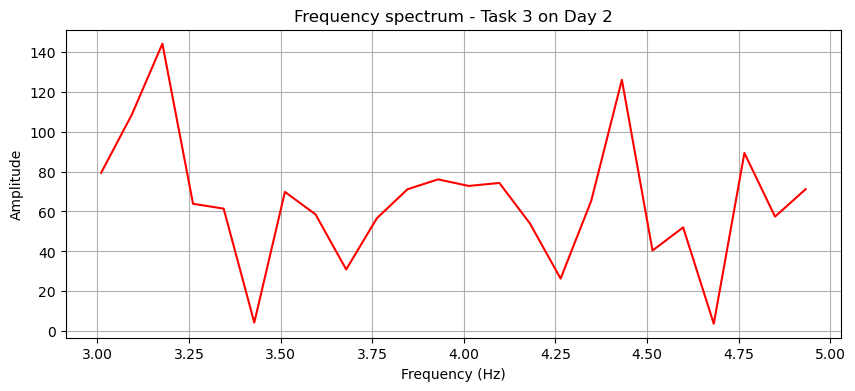

In [74]:
# Define Task 3 - Day 2
task3_d2 = df_2[(df_2["Time (s)"] >= 348) & (df_2["Time (s)"] <= 360)]

# Signal
signal_task3_d2 = task3_d2["magnitude"].values

# Remove mean
signal_centered_task3_d2 = signal_task3_d2 - np.mean(signal_task3_d2)

# Sampling frequency
fs = 100

# FFT
fft_vals_task3_d2 = np.abs(np.fft.fft(signal_centered_task3_d2))
freqs_task3_d2 = np.fft.fftfreq(len(signal_centered_task3_d2), d=1/fs)

# Keep positive frequencies
positive_freqs_task3_d2 = freqs_task3_d2[:len(freqs_task3_d2)//2]
positive_fft_task3_d2 = fft_vals_task3_d2[:len(fft_vals_task3_d2)//2]

# Mask 3–5 Hz
mask_task3_d2 = (positive_freqs_task3_d2 >= 3) & (positive_freqs_task3_d2 <= 5)

# Dominant frequency
dominant_freq_task3_d2 = positive_freqs_task3_d2[mask_task3_d2][np.argmax(positive_fft_task3_d2[mask_task3_d2])]

print("Dominant frequency - Task 3 on Day 2:", dominant_freq_task3_d2, "Hz")

# RMS amplitude
rms_task3_d2 = np.sqrt(np.mean(signal_centered_task3_d2**2))
print("RMS amplitude - Task 3 on Day 2:", rms_task3_d2)

# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_task3_d2[mask_task3_d2], positive_fft_task3_d2[mask_task3_d2], color="red")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Task 3 on Day 2")
plt.grid(True)
plt.show()

#### 6.7 Rest 4 on day 2 : 

Dominant frequency - Rest 4 on Day 2: 3.0381198051017484 Hz
RMS amplitude - Rest 4 on Day 2: 0.15219852909659273


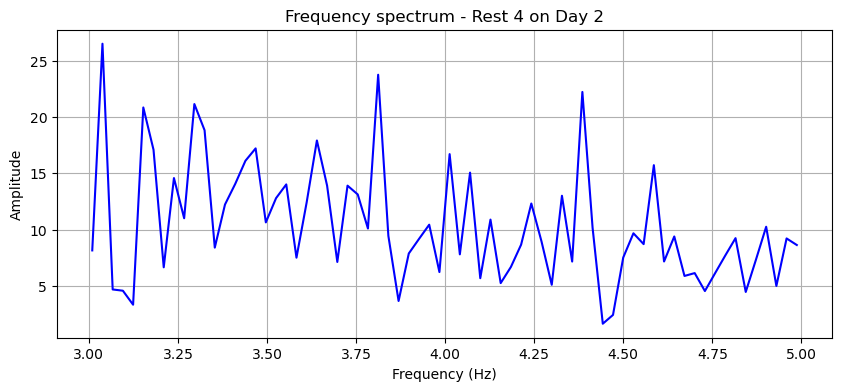

In [75]:
# Define Rest 4 - Day 2
rest4_d2 = df_2[(df_2["Time (s)"] >= 360) & (df_2["Time (s)"] <= 395)]

# Signal
signal_rest4_d2 = rest4_d2["magnitude"].values

# Remove mean
signal_centered_rest4_d2 = signal_rest4_d2 - np.mean(signal_rest4_d2)

# Sampling frequency
fs = 100

# FFT
fft_vals_rest4_d2 = np.abs(np.fft.fft(signal_centered_rest4_d2))
freqs_rest4_d2 = np.fft.fftfreq(len(signal_centered_rest4_d2), d=1/fs)

# Keep positive frequencies
positive_freqs_rest4_d2 = freqs_rest4_d2[:len(freqs_rest4_d2)//2]
positive_fft_rest4_d2 = fft_vals_rest4_d2[:len(fft_vals_rest4_d2)//2]

# Mask 3–5 Hz
mask_rest4_d2 = (positive_freqs_rest4_d2 >= 3) & (positive_freqs_rest4_d2 <= 5)

# Dominant frequency
dominant_freq_rest4_d2 = positive_freqs_rest4_d2[mask_rest4_d2][np.argmax(positive_fft_rest4_d2[mask_rest4_d2])]

print("Dominant frequency - Rest 4 on Day 2:", dominant_freq_rest4_d2, "Hz")

# RMS amplitude
rms_rest4_d2 = np.sqrt(np.mean(signal_centered_rest4_d2**2))
print("RMS amplitude - Rest 4 on Day 2:", rms_rest4_d2)

# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_rest4_d2[mask_rest4_d2], positive_fft_rest4_d2[mask_rest4_d2], color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Rest 4 on Day 2")
plt.grid(True)
plt.show()

###  7. Create DataFrame for Day 2 


In [76]:
import pandas as pd

results_day2 = pd.DataFrame({
    "Day": ["D2"]*7,
    "Phase": ["Rest1","Task1","Rest2","Task2","Rest3","Task3","Rest4"],
    "Condition": ["Rest","Task","Rest","Task","Rest","Task","Rest"],
    "Repetition": [1,1,2,2,3,3,4],
    "Dominant_Frequency_Hz": [
        dominant_freq_rest1_d2,
        dominant_freq_task1_d2,
        dominant_freq_rest2_d2,
        dominant_freq_task2_d2,
        dominant_freq_rest3_d2,
        dominant_freq_task3_d2,
        dominant_freq_rest4_d2
    ],
    "RMS_Amplitude": [
        rms_rest1_d2,
        rms_task1_d2,
        rms_rest2_d2,
        rms_task2_d2,
        rms_rest3_d2,
        rms_task3_d2,
        rms_rest4_d2
    ]
})

# Arrondir
results_day2 = results_day2.round(2)

results_day2

,Day,Phase,Condition,Repetition,Dominant_Frequency_Hz,RMS_Amplitude
0,D2,Rest1,Rest,1,4.52,0.08
1,D2,Task1,Task,1,3.18,0.86
2,D2,Rest2,Rest,2,4.73,0.08
3,D2,Task2,Task,2,4.15,0.88
4,D2,Rest3,Rest,3,3.48,0.12
5,D2,Task3,Task,3,3.18,1.15
6,D2,Rest4,Rest,4,3.04,0.15


In [77]:
results_day2.to_csv("data/processed_data/results_day2.csv", index=False)

# ------------------------------------- DAY 3 --------------------------------

### 1. Import J3_P01.csv

In [30]:
df_3 = pd.read_csv("data/raw_data/J3_P01.csv")
df.head()


,Time (s),X (m/s^2),Y (m/s^2),Z (m/s^2),magnitude
0,0.002665,0.506471,-0.356188,0.234163,0.661978
1,0.012697,0.032052,-0.225771,-0.058613,0.235447
2,0.022728,-1.409056,0.168511,-0.354232,1.462639
3,0.032759,-0.614877,0.402211,-0.335070,0.807539
4,0.042790,-0.136440,0.013456,-0.319703,0.347860


In [31]:
print(df_3.columns)
print(df_3.shape)

Index(['Time (s)', 'X (m/s^2)', 'Y (m/s^2)', 'Z (m/s^2)'], dtype='object')
(68281, 4)


### 2. Draw the signal

Plot the raw signals
- X axis :


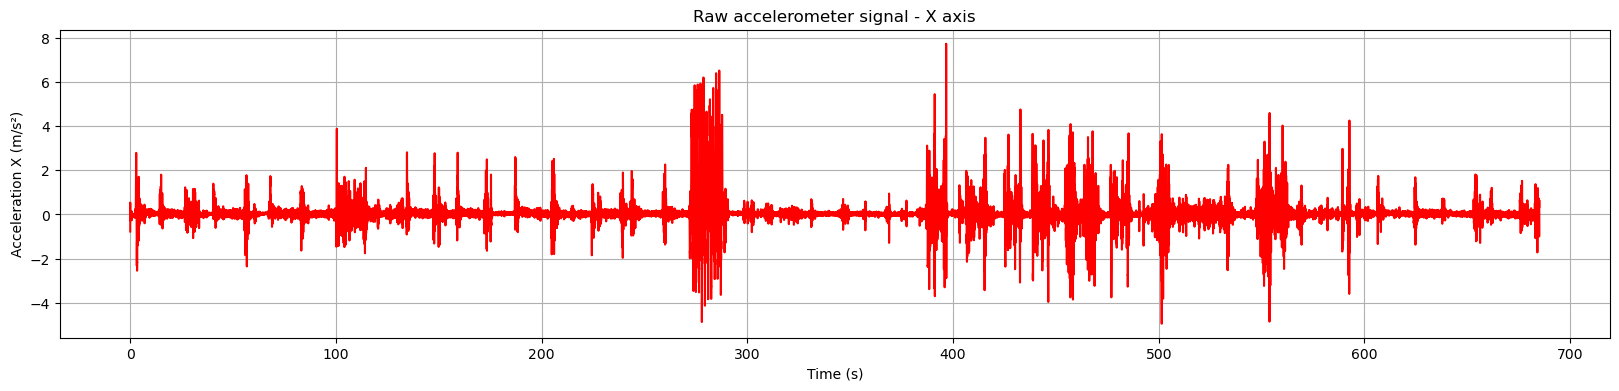

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,4))
plt.plot(df_3["Time (s)"], df_3["X (m/s^2)"], color="red")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration X (m/s²)")
plt.title("Raw accelerometer signal - X axis")
plt.grid(True)
plt.box(True)
plt.show()

- Y axis : 

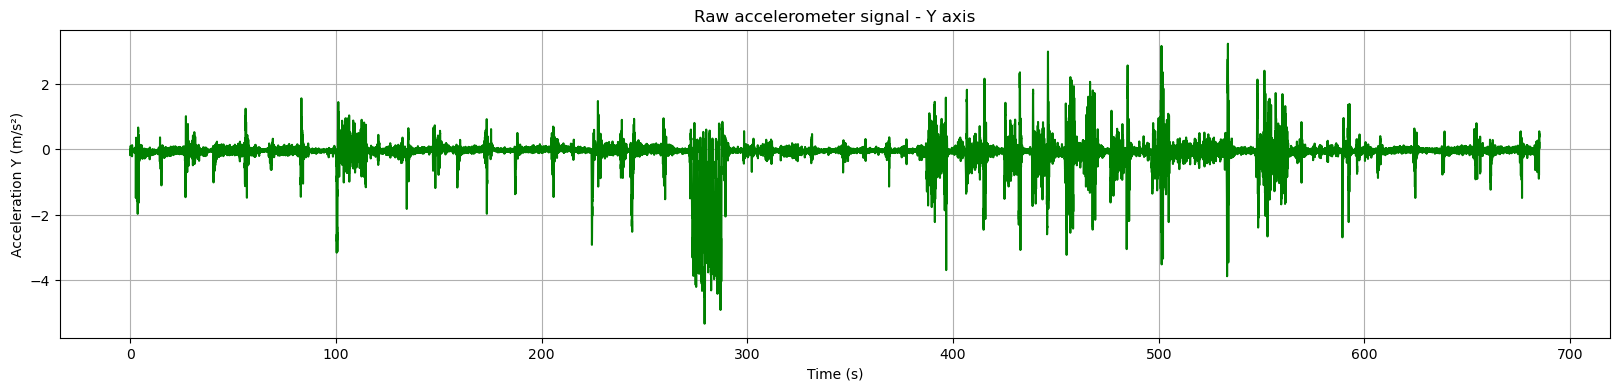

In [79]:
plt.figure(figsize=(20,4))
plt.plot(df_3["Time (s)"], df_3["Y (m/s^2)"], color="green")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration Y (m/s²)")
plt.title("Raw accelerometer signal - Y axis")
plt.grid(True)
plt.box(True)
plt.show()

- Z axis :

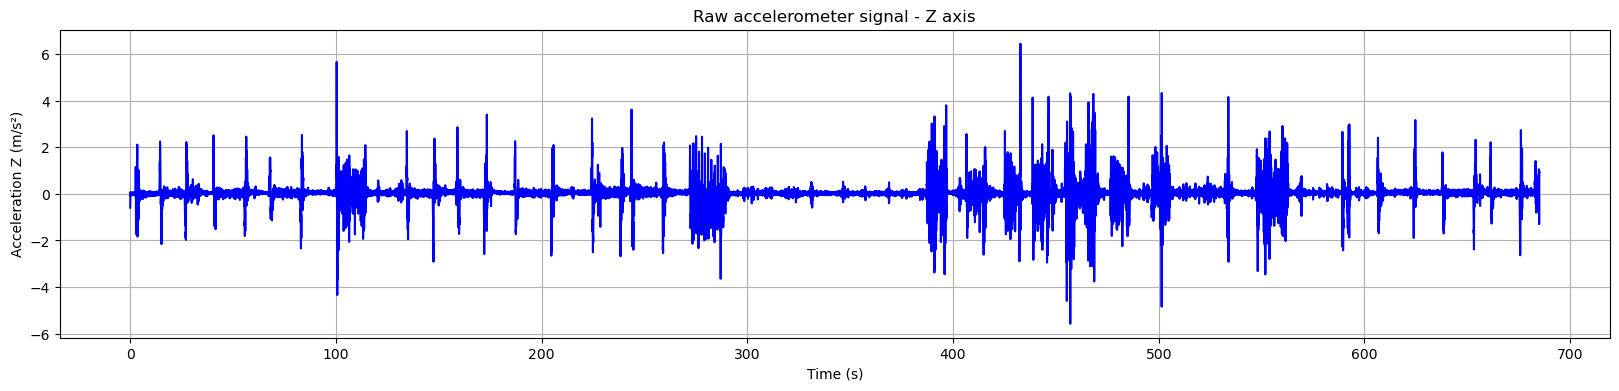

In [80]:
plt.figure(figsize=(20,4))
plt.plot(df_3["Time (s)"], df_3["Z (m/s^2)"], color="blue")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration Z (m/s²)")
plt.title("Raw accelerometer signal - Z axis")
plt.grid(True)
plt.box(True)
plt.show()

### 3. Calculat magnitude - Global signal

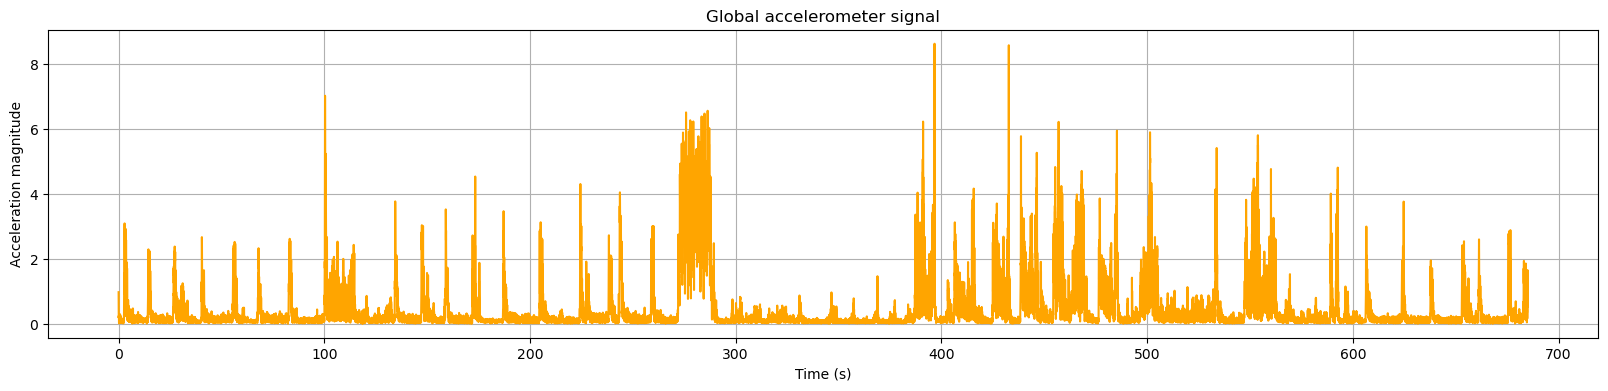

In [81]:
import numpy as np

df_3["magnitude"] = np.sqrt(
    df_3["X (m/s^2)"]**2 +
    df_3["Y (m/s^2)"]**2 +
    df_3["Z (m/s^2)"]**2
)

plt.figure(figsize=(20,4))
plt.plot(df_3["Time (s)"], df_3["magnitude"], color="orange")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration magnitude")
plt.title("Global accelerometer signal")
plt.grid(True)
plt.show()

### 4. Zoom on the task window :

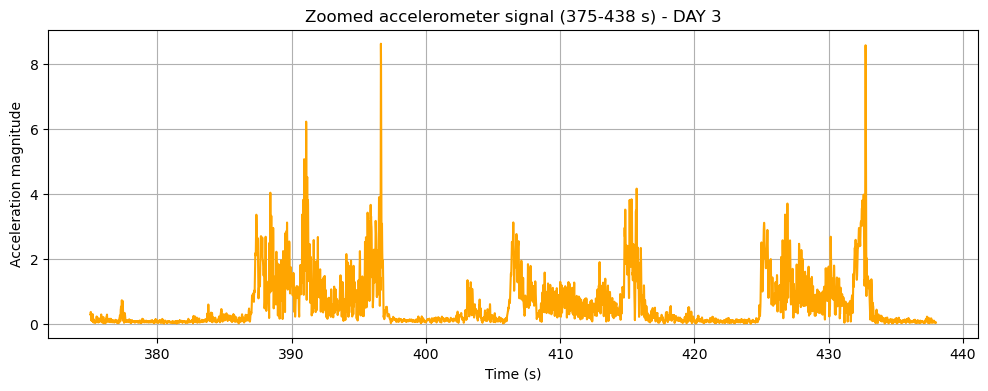

In [85]:
import matplotlib.pyplot as plt

# Sélection du segment
zoom_segment3 = df_3[(df_3["Time (s)"] >= 375) & (df_3["Time (s)"] <= 438)]

plt.figure(figsize=(12,4))

# Signal
plt.plot(zoom_segment3["Time (s)"], zoom_segment3["magnitude"], color="orange")

plt.xlabel("Time (s)")
plt.ylabel("Acceleration magnitude")
plt.title("Zoomed accelerometer signal (375-438 s) - DAY 3")
plt.grid(True)

plt.show()

#### 5. Segment rest/task Day 3 

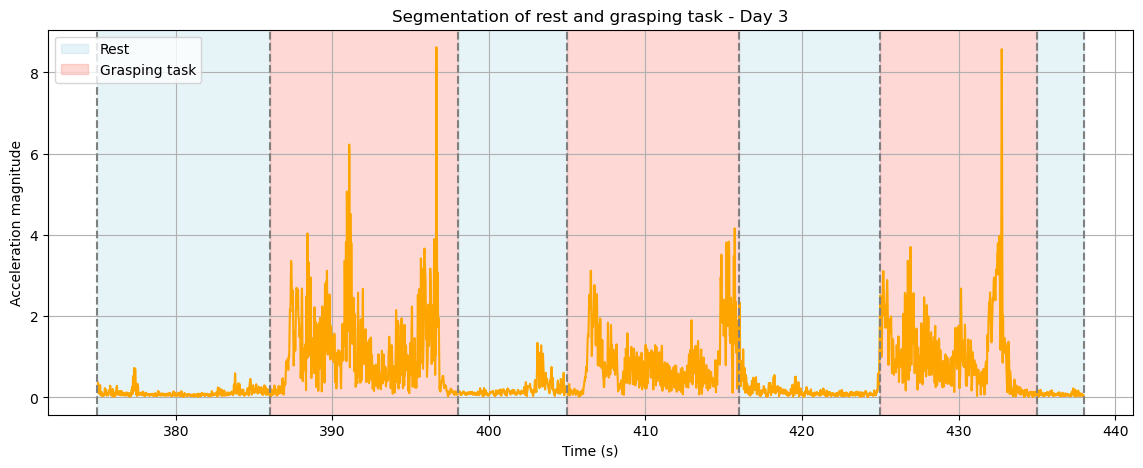

In [88]:
import matplotlib.pyplot as plt

# Segment times for Day 3

start_total_d3 = 375

rest1_start_d3 = 375

rest1_end_d3 = 386

task1_start_d3 = 386

task1_end_d3 = 398

rest2_start_d3 = 398

rest2_end_d3 = 405

task2_start_d3 = 405

task2_end_d3 = 416

rest3_start_d3 = 416

rest3_end_d3 = 425

task3_start_d3 = 425

task3_end_d3 = 435

rest4_start_d3 = 435

rest4_end_d3 = 438

end_total_d3 = 438

# Select the segment

segment_j3 = df_3[(df_3["Time (s)"] >= start_total_d3) & (df_3["Time (s)"] <= end_total_d3)]

plt.figure(figsize=(14,5))

# Plot signal

plt.plot(segment_j3["Time (s)"], segment_j3["magnitude"], color="orange")

# Background colors

plt.axvspan(rest1_start_d3, rest1_end_d3, color="lightblue", alpha=0.3, label="Rest")

plt.axvspan(task1_start_d3, task1_end_d3, color="salmon", alpha=0.3, label="Grasping task")

plt.axvspan(rest2_start_d3, rest2_end_d3, color="lightblue", alpha=0.3)

plt.axvspan(task2_start_d3, task2_end_d3, color="salmon", alpha=0.3)

plt.axvspan(rest3_start_d3, rest3_end_d3, color="lightblue", alpha=0.3)

plt.axvspan(task3_start_d3, task3_end_d3, color="salmon", alpha=0.3)

plt.axvspan(rest4_start_d3, rest4_end_d3, color="lightblue", alpha=0.3)

# Separation lines

for x in [rest1_start_d3,rest1_end_d3, task1_end_d3, rest2_end_d3, task2_end_d3, rest3_end_d3, task3_end_d3, rest4_end_d3]:

    plt.axvline(x, linestyle="--", color="gray")

# Labels

plt.xlabel("Time (s)")

plt.ylabel("Acceleration magnitude")

plt.title("Segmentation of rest and grasping task - Day 3")

plt.grid(True)

plt.legend()

plt.show()


#### 6.1. Rest 1 on Day 3

Dominant frequency - Rest 1 on Day 3: 4.37956204379562 Hz
RMS amplitude - Rest 1 on Day 3: 0.08716113027716664


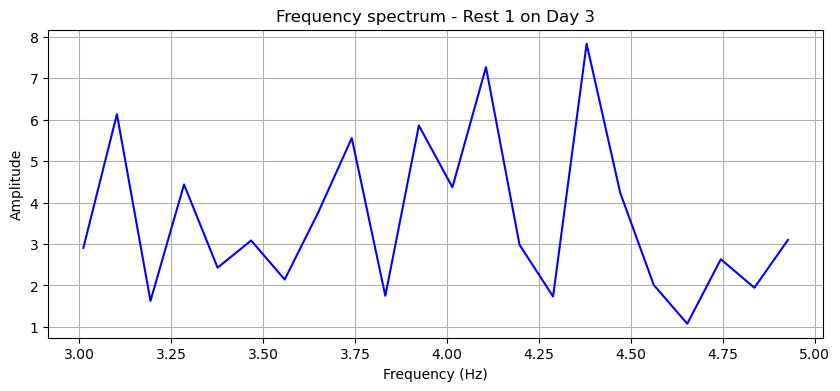

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# Define Rest 1 - Day 3
rest1_d3 = df_3[(df_3["Time (s)"] >= 375) & (df_3["Time (s)"] <= 386)]

# Signal
signal_rest1_d3 = rest1_d3["magnitude"].values

# Remove mean
signal_centered_rest1_d3 = signal_rest1_d3 - np.mean(signal_rest1_d3)

# Sampling frequency
fs = 100

# FFT
fft_vals_rest1_d3 = np.abs(np.fft.fft(signal_centered_rest1_d3))
freqs_rest1_d3 = np.fft.fftfreq(len(signal_centered_rest1_d3), d=1/fs)

# Keep positive frequencies
positive_freqs_rest1_d3 = freqs_rest1_d3[:len(freqs_rest1_d3)//2]
positive_fft_rest1_d3 = fft_vals_rest1_d3[:len(fft_vals_rest1_d3)//2]

# Mask 3–5 Hz
mask_rest1_d3 = (positive_freqs_rest1_d3 >= 3) & (positive_freqs_rest1_d3 <= 5)

# Dominant frequency
dominant_freq_rest1_d3 = positive_freqs_rest1_d3[mask_rest1_d3][
    np.argmax(positive_fft_rest1_d3[mask_rest1_d3])
]

print("Dominant frequency - Rest 1 on Day 3:", dominant_freq_rest1_d3, "Hz")

# RMS amplitude
rms_rest1_d3 = np.sqrt(np.mean(signal_centered_rest1_d3**2))
print("RMS amplitude - Rest 1 on Day 3:", rms_rest1_d3)

# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_rest1_d3[mask_rest1_d3], positive_fft_rest1_d3[mask_rest1_d3], color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Rest 1 on Day 3")
plt.grid(True)
plt.show()

#### 6.2 Task 2 on Day 3 

Dominant frequency - Task 1 on Day 3: 3.762541806020067 Hz
RMS amplitude - Task 1 on Day 3: 0.994689090326094


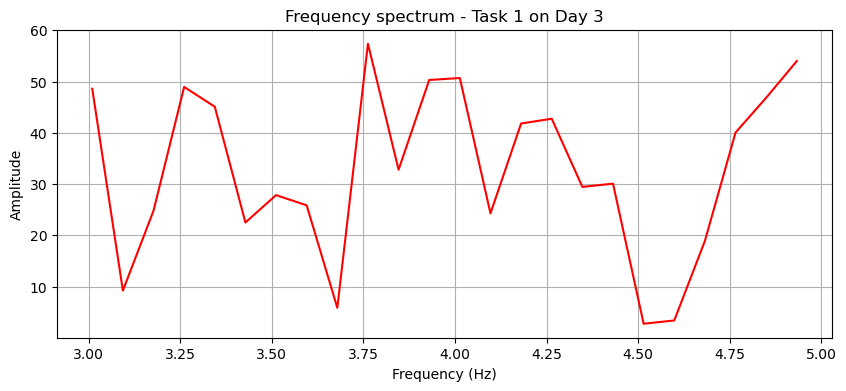

In [90]:
# Define Task 1 - Day 3
task1_d3 = df_3[(df_3["Time (s)"] >= 386) & (df_3["Time (s)"] <= 398)]

# Signal
signal_task1_d3 = task1_d3["magnitude"].values

# Remove mean
signal_centered_task1_d3 = signal_task1_d3 - np.mean(signal_task1_d3)

# Sampling frequency
fs = 100

# FFT
fft_vals_task1_d3 = np.abs(np.fft.fft(signal_centered_task1_d3))
freqs_task1_d3 = np.fft.fftfreq(len(signal_centered_task1_d3), d=1/fs)

# Keep positive frequencies
positive_freqs_task1_d3 = freqs_task1_d3[:len(freqs_task1_d3)//2]
positive_fft_task1_d3 = fft_vals_task1_d3[:len(fft_vals_task1_d3)//2]

# Mask 3–5 Hz
mask_task1_d3 = (positive_freqs_task1_d3 >= 3) & (positive_freqs_task1_d3 <= 5)

# Dominant frequency
dominant_freq_task1_d3 = positive_freqs_task1_d3[mask_task1_d3][np.argmax(positive_fft_task1_d3[mask_task1_d3])]

print("Dominant frequency - Task 1 on Day 3:", dominant_freq_task1_d3, "Hz")

# RMS amplitude
rms_task1_d3 = np.sqrt(np.mean(signal_centered_task1_d3**2))
print("RMS amplitude - Task 1 on Day 3:", rms_task1_d3)

# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_task1_d3[mask_task1_d3], positive_fft_task1_d3[mask_task1_d3], color="red")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Task 1 on Day 3")
plt.grid(True)
plt.show()

#### 6.3 Rest 2 on day 3 

Dominant frequency - Rest 2 on Day 3: 3.5816618911174785 Hz
RMS amplitude - Rest 2 on Day 3: 0.20527107910955739


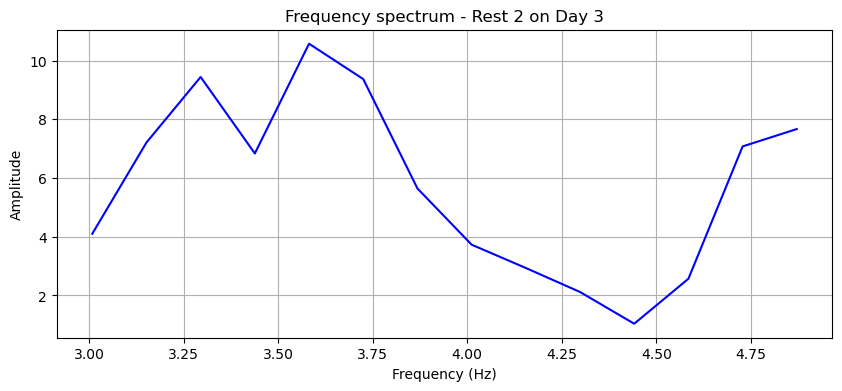

In [91]:
# Define Rest 2 - Day 3
rest2_d3 = df_3[(df_3["Time (s)"] >= 398) & (df_3["Time (s)"] <= 405)]

# Signal
signal_rest2_d3 = rest2_d3["magnitude"].values

# Remove mean
signal_centered_rest2_d3 = signal_rest2_d3 - np.mean(signal_rest2_d3)

# Sampling frequency
fs = 100

# FFT
fft_vals_rest2_d3 = np.abs(np.fft.fft(signal_centered_rest2_d3))
freqs_rest2_d3 = np.fft.fftfreq(len(signal_centered_rest2_d3), d=1/fs)

# Keep positive frequencies
positive_freqs_rest2_d3 = freqs_rest2_d3[:len(freqs_rest2_d3)//2]
positive_fft_rest2_d3 = fft_vals_rest2_d3[:len(fft_vals_rest2_d3)//2]

# Mask 3–5 Hz
mask_rest2_d3 = (positive_freqs_rest2_d3 >= 3) & (positive_freqs_rest2_d3 <= 5)

# Dominant frequency
dominant_freq_rest2_d3 = positive_freqs_rest2_d3[mask_rest2_d3][np.argmax(positive_fft_rest2_d3[mask_rest2_d3])]

print("Dominant frequency - Rest 2 on Day 3:", dominant_freq_rest2_d3, "Hz")

# RMS amplitude
rms_rest2_d3 = np.sqrt(np.mean(signal_centered_rest2_d3**2))
print("RMS amplitude - Rest 2 on Day 3:", rms_rest2_d3)

# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_rest2_d3[mask_rest2_d3], positive_fft_rest2_d3[mask_rest2_d3], color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Rest 2 on Day 3")
plt.grid(True)
plt.show()

#### 6.4. Task 2 on day 3 

Dominant frequency - Task 2 on Day 3: 3.4639927073837735 Hz
RMS amplitude - Task 2 on Day 3: 0.7185715073644121


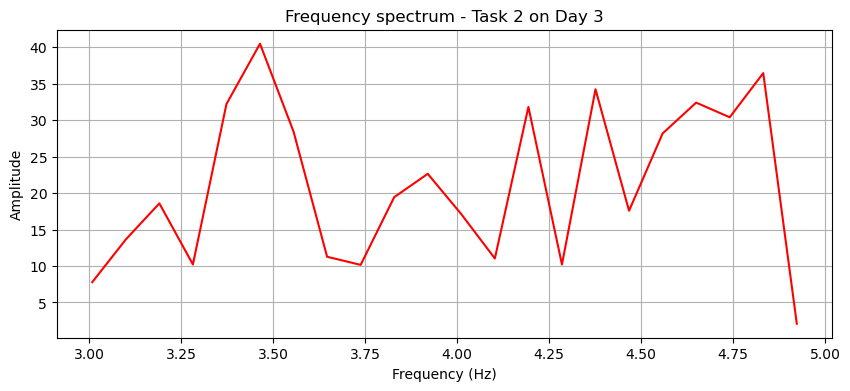

In [92]:
# Define Task 2 - Day 3
task2_d3 = df_3[(df_3["Time (s)"] >= 405) & (df_3["Time (s)"] <= 416)]

# Signal
signal_task2_d3 = task2_d3["magnitude"].values

# Remove mean
signal_centered_task2_d3 = signal_task2_d3 - np.mean(signal_task2_d3)

# Sampling frequency
fs = 100

# FFT
fft_vals_task2_d3 = np.abs(np.fft.fft(signal_centered_task2_d3))
freqs_task2_d3 = np.fft.fftfreq(len(signal_centered_task2_d3), d=1/fs)

# Keep positive frequencies
positive_freqs_task2_d3 = freqs_task2_d3[:len(freqs_task2_d3)//2]
positive_fft_task2_d3 = fft_vals_task2_d3[:len(fft_vals_task2_d3)//2]

# Mask 3–5 Hz
mask_task2_d3 = (positive_freqs_task2_d3 >= 3) & (positive_freqs_task2_d3 <= 5)

# Dominant frequency
dominant_freq_task2_d3 = positive_freqs_task2_d3[mask_task2_d3][np.argmax(positive_fft_task2_d3[mask_task2_d3])]

print("Dominant frequency - Task 2 on Day 3:", dominant_freq_task2_d3, "Hz")

# RMS amplitude
rms_task2_d3 = np.sqrt(np.mean(signal_centered_task2_d3**2))
print("RMS amplitude - Task 2 on Day 3:", rms_task2_d3)

# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_task2_d3[mask_task2_d3], positive_fft_task2_d3[mask_task2_d3], color="red")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Task 2 on Day 3")
plt.grid(True)
plt.show()

#### 6.5 Rest 3 on day 3 

Dominant frequency - Rest 3 on Day 3: 3.0100334448160533 Hz
RMS amplitude - Rest 3 on Day 3: 0.24140591702109238


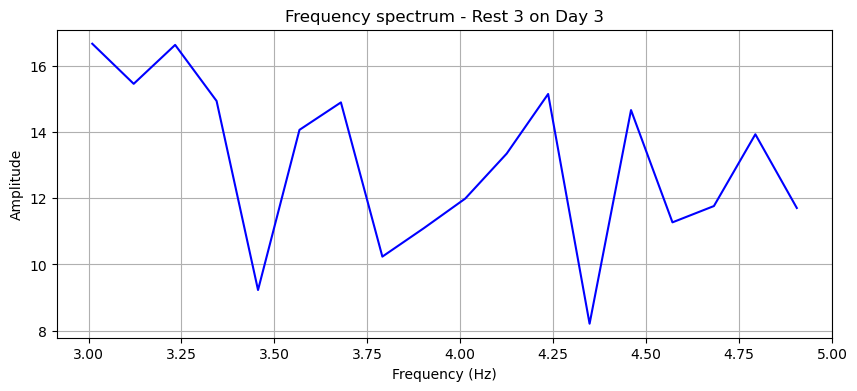

In [93]:
# Define Rest 3 - Day 3
rest3_d3 = df_3[(df_3["Time (s)"] >= 416) & (df_3["Time (s)"] <= 425)]

# Signal
signal_rest3_d3 = rest3_d3["magnitude"].values

# Remove mean
signal_centered_rest3_d3 = signal_rest3_d3 - np.mean(signal_rest3_d3)

# Sampling frequency
fs = 100

# FFT
fft_vals_rest3_d3 = np.abs(np.fft.fft(signal_centered_rest3_d3))
freqs_rest3_d3 = np.fft.fftfreq(len(signal_centered_rest3_d3), d=1/fs)

# Keep positive frequencies
positive_freqs_rest3_d3 = freqs_rest3_d3[:len(freqs_rest3_d3)//2]
positive_fft_rest3_d3 = fft_vals_rest3_d3[:len(fft_vals_rest3_d3)//2]

# Mask 3–5 Hz
mask_rest3_d3 = (positive_freqs_rest3_d3 >= 3) & (positive_freqs_rest3_d3 <= 5)

# Dominant frequency
dominant_freq_rest3_d3 = positive_freqs_rest3_d3[mask_rest3_d3][np.argmax(positive_fft_rest3_d3[mask_rest3_d3])]

print("Dominant frequency - Rest 3 on Day 3:", dominant_freq_rest3_d3, "Hz")

# RMS amplitude
rms_rest3_d3 = np.sqrt(np.mean(signal_centered_rest3_d3**2))
print("RMS amplitude - Rest 3 on Day 3:", rms_rest3_d3)

# Plot
plt.figure(figsize=(10,4))
plt.plot(positive_freqs_rest3_d3[mask_rest3_d3], positive_fft_rest3_d3[mask_rest3_d3], color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum - Rest 3 on Day 3")
plt.grid(True)
plt.show()